# 00. ACOS Master Pipeline: End-to-End Colab Execution

**Aspect-Category-Opinion-Sentiment (ACOS) Quadruple Extraction with Implicit Aspects and Opinions**

This master notebook allows you to run the **entire ACOS benchmark pipeline with 1-Click** on **Google Colab** (or Local environment):
1. **Environment Setup & GPU Check:** Google Drive mounting, package installation (`pytorch-crf`, `transformers`), and hardware verification.
2. **BERT Caching:** Downloads `bert-base-uncased` locally to eliminate legacy S3 download failures.
3. **Timestamped Directory Architecture:** Automatically generates `results/<domain>_<DDMMYYYY_HMS>/` with isolated subfolders for `plots/`, `csv/`, `checkpoints/`, and `logs/`.
4. **Exploratory Data Analysis (EDA):** Analyzes `Restaurant-ACOS` / `Laptop-ACOS` with high-resolution charts.
5. **Step 1 (Aspect-Opinion Co-Extraction):** Trains and evaluates BERT-CRF, saves the best checkpoint to `checkpoints/step1_best/`, and generates `pred4pipeline.txt`.
6. **Candidate Pair Generation Bridge:** Builds Cartesian candidate pairs `(aspect, opinion)` including implicit entities `[-1, -1]`.
7. **Step 2 (Category-Sentiment Classification):** Trains and evaluates multi-label BERT classifier, saves checkpoint to `checkpoints/step2_best/`, and predicts final quadruples.
8. **Benchmark Dashboard & Metric Exports:** Computes performance across all 15 subtasks and 4 implicit/explicit subsets, saving full CSV reports and figures.
9. **Interactive Live Demo:** Input custom customer reviews and extract color-coded ACOS quadruples in real time!

## 1. Google Drive Mounting & Colab Setup (Optional)

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive Mounted.")
except Exception:
    print("💻 Running without Colab Drive mount.")

# Install dependencies
!pip install -q pytorch-crf transformers huggingface_hub seaborn scikit-learn matplotlib pandas boto3

import os
import sys
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ PyTorch Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU Model: {torch.cuda.get_device_name(0)}")


💻 Running without Colab Drive mount.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
⚡ PyTorch Device: cuda
   GPU Model: AMD Instinct MI300X VF


## 2. Directory Navigation & Path Initialization

In [2]:
import os
import sys
import shutil

# 1. Pastikan base project directory ada di dalam folder induk ACOS
if os.path.exists("/content/drive/MyDrive"):
    base_project_dir = "/content/drive/MyDrive/ACOS"
    os.makedirs(base_project_dir, exist_ok=True)

    # Pindahkan folder jika sebelumnya telanjur tersimpan di root Drive
    if os.path.exists("/content/drive/MyDrive/Extract-Classify-ACOS"):
        print("📦 Memindahkan Extract-Classify-ACOS dari root Drive ke dalam folder ACOS...")
        try:
            shutil.move("/content/drive/MyDrive/Extract-Classify-ACOS", os.path.join(base_project_dir, "Extract-Classify-ACOS"))
        except Exception as e:
            print(f"⚠️ Gagal memindahkan Extract-Classify-ACOS: {e}")

    if os.path.exists("/content/drive/MyDrive/data") and not os.path.exists(os.path.join(base_project_dir, "data")):
        print("📦 Memindahkan folder data dari root Drive ke dalam folder ACOS...")
        try:
            shutil.move("/content/drive/MyDrive/data", os.path.join(base_project_dir, "data"))
        except Exception as e:
            print(f"⚠️ Gagal memindahkan data: {e}")

elif os.path.exists("/content/ACOS/Extract-Classify-ACOS"):
    base_project_dir = "/content/ACOS"
elif os.path.exists("Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath(".")
elif os.path.exists("../Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath("..")
else:
    base_project_dir = os.path.abspath("ACOS")
    os.makedirs(base_project_dir, exist_ok=True)

# 2. Deteksi dan Clone Repositori jika belum ada
if not os.path.exists(os.path.join(base_project_dir, "Extract-Classify-ACOS")):
    print(f"📥 Cloning ACOS repository ke dalam {base_project_dir}...")
    !git clone https://github.com/haisyamalawwab/ACOS.git /tmp/ACOS_clone
    !cp -r /tmp/ACOS_clone/* "{base_project_dir}/"
    !rm -rf /tmp/ACOS_clone

# 2b. Define save directory (untuk hasil, plot, log, cache model)
if os.path.exists("/content/drive/MyDrive"):
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Output akan disimpan di Google Drive: {save_dir}")
else:
    save_dir = base_project_dir
    print("💾 Output akan disimpan secara lokal")

extract_dir = os.path.join(base_project_dir, "Extract-Classify-ACOS")
notebooks_dir = os.path.join(base_project_dir, "notebooks")

for p in [base_project_dir, extract_dir, notebooks_dir]:
    if p not in sys.path:
        sys.path.insert(0, p)

# 3. Import colab_utils dengan fallback download
try:
    from colab_utils import (
        setup_timestamped_run_dir, download_bert_pretrained, analyze_and_plot_eda,
        plot_training_history, export_benchmark_tables_and_plots,
        display_quadruple_dataframe, df_to_markdown, export_step_table,
        MarkdownReport, SubtaskMetricCapture, plot_subtask_metrics,
        features_step1, features_step2, pair_examples_from_file,
        resolve_eval_pair_file, unpack_model_output,
    )
except ModuleNotFoundError:
    import urllib.request
    print("⚠️ Downloading colab_utils.py fallback directly from GitHub...")
    raw_url = "https://raw.githubusercontent.com/haisyamalawwab/ACOS/main/notebooks/colab_utils.py"
    urllib.request.urlretrieve(raw_url, os.path.join(base_project_dir, "colab_utils.py"))
    from colab_utils import (
        setup_timestamped_run_dir, download_bert_pretrained, analyze_and_plot_eda,
        plot_training_history, export_benchmark_tables_and_plots,
        display_quadruple_dataframe, df_to_markdown, export_step_table,
        MarkdownReport, SubtaskMetricCapture, plot_subtask_metrics,
        features_step1, features_step2, pair_examples_from_file,
        resolve_eval_pair_file, unpack_model_output,
    )

print(f"📂 Base project directory: {base_project_dir}")
print(f"📁 Extract & Model directory: {extract_dir}")
print(f"📁 Save directory (Results & Caches): {save_dir}")

📥 Cloning ACOS repository ke dalam /shared-docker/ACOS...
Cloning into '/tmp/ACOS_clone'...
remote: Enumerating objects: 1829, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 1829 (delta 61), reused 35 (delta 35), pack-reused 1739 (from 2)
Receiving objects: 100% (1829/1829), 51.89 MiB | 39.30 MiB/s, done.
Resolving deltas: 100% (977/977), done.
💾 Output akan disimpan secara lokal
📂 Base project directory: /shared-docker/ACOS
📁 Extract & Model directory: /shared-docker/ACOS/Extract-Classify-ACOS
📁 Save directory (Results & Caches): /shared-docker/ACOS


## 3. Master Pipeline Parameters & Session Initialization

In [3]:
# Choose dataset domain: 'rest16' (Restaurant-ACOS) or 'laptop' (Laptop-ACOS)
DOMAIN = "rest16"

# Hyperparameters
MAX_SEQ_LENGTH = 128
STEP1_BATCH_SIZE = 24
STEP2_BATCH_SIZE = 16
STEP1_LR = 2e-5
STEP2_LR = 5e-5
NUM_EPOCHS = 15      # Default in paper is 30; 15 is optimal for Colab training
SEED = 42

# Set seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

active_save_dir = save_dir if 'save_dir' in locals() else base_project_dir

# 1. Initialize Timestamped Directory (DDMMYYYY_HMS)
results_base = os.path.join(active_save_dir, "results")
session_dirs = setup_timestamped_run_dir(base_dir=results_base, domain=DOMAIN)

# 2. Download and Cache Pretrained BERT
bert_cache_dir = os.path.join(active_save_dir, "bert_base_uncased")
download_bert_pretrained(target_dir=bert_cache_dir)

print(f"\n📁 Active Session Folder: {session_dirs['root']}")
plots_dir = session_dirs["plots"]
csv_dir = session_dirs["csv"]
md_dir = session_dirs["md"]
logs_dir = session_dirs["logs"]

rep = MarkdownReport(
    f"00 - Master Pipeline ACOS End-to-End [{DOMAIN.upper()}]",
    md_dir,
    filename="00_master_pipeline.md",
    meta={
        "domain": DOMAIN, "epochs": NUM_EPOCHS,
        "step1_batch": STEP1_BATCH_SIZE, "step2_batch": STEP2_BATCH_SIZE,
        "step1_lr": STEP1_LR, "step2_lr": STEP2_LR,
        "max_seq_length": MAX_SEQ_LENGTH, "seed": SEED,
        "device": str(device), "session_dir": session_dirs["root"],
    },
)

df_cfg = pd.DataFrame([
    {"Parameter": "domain", "Nilai": DOMAIN},
    {"Parameter": "num_epochs", "Nilai": NUM_EPOCHS},
    {"Parameter": "step1_batch_size", "Nilai": STEP1_BATCH_SIZE},
    {"Parameter": "step2_batch_size", "Nilai": STEP2_BATCH_SIZE},
    {"Parameter": "step1_learning_rate", "Nilai": STEP1_LR},
    {"Parameter": "step2_learning_rate", "Nilai": STEP2_LR},
    {"Parameter": "max_seq_length", "Nilai": MAX_SEQ_LENGTH},
    {"Parameter": "seed", "Nilai": SEED},
    {"Parameter": "device", "Nilai": str(device)},
])
rep.section("1. Konfigurasi pipeline")
export_step_table(df_cfg, name="master_00_konfigurasi", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Konfigurasi Master Pipeline ({DOMAIN.upper()})")
rep.table(df_cfg, caption="Hyperparameter")

📁 Initialized timestamped session directory: /shared-docker/ACOS/results/rest16_24092026_0849
📥 Downloading config.json to /shared-docker/ACOS/bert_base_uncased/config.json ...
📥 Downloading pytorch_model.bin to /shared-docker/ACOS/bert_base_uncased/pytorch_model.bin ...
📥 Downloading vocab.txt to /shared-docker/ACOS/bert_base_uncased/vocab.txt ...

📁 Active Session Folder: /shared-docker/ACOS/results/rest16_24092026_0849
=== Konfigurasi Master Pipeline (REST16) (9 baris) ===


,Parameter,Nilai
0,domain,rest16
1,num_epochs,15
2,step1_batch_size,24
3,step2_batch_size,16
4,step1_learning_rate,0.00002
5,step2_learning_rate,0.00005
6,max_seq_length,128
7,seed,42
8,device,cuda


[tabel] CSV: /shared-docker/ACOS/results/rest16_24092026_0849/csv/master_00_konfigurasi.csv | MD: /shared-docker/ACOS/results/rest16_24092026_0849/md/master_00_konfigurasi.md


## 4. Exploratory Data Analysis (EDA) & Visualization

📊 Saved EDA Statistics CSV: /shared-docker/ACOS/results/rest16_24092026_0849/csv/eda_dataset_statistics.csv


/shared-docker/ACOS/notebooks/colab_utils.py:673: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_cats.index, x=top_cats.values, ax=axes[0], palette="viridis")


=== Statistik Dataset REST16 per Split (3 baris) ===


,Domain,Split,Sentences,Total_Quadruples,Explicit_Aspects,Implicit_Aspects,Explicit_Opinions,Implicit_Opinions,Negative_Count (0),Neutral_Count (1),Positive_Count (2)
0,rest16,train,1530,2484,1877,607,2036,448,733,95,1656
1,rest16,dev,171,261,201,60,207,54,69,12,180
2,rest16,test,583,916,703,213,718,198,205,44,667


[tabel] CSV: /shared-docker/ACOS/results/rest16_24092026_0849/csv/master_01_statistik_dataset.csv | MD: /shared-docker/ACOS/results/rest16_24092026_0849/md/master_01_statistik_dataset.md
=== Ringkasan EDA (REST16) (1 baris) ===


,Total_Quadruple,Implicit_Aspect,Implicit_Opinion,Keduanya_Implicit,Kategori_Unik,Panjang_Kalimat_Median
0,3661,880,700,350,13,15.0


[tabel] CSV: /shared-docker/ACOS/results/rest16_24092026_0849/csv/master_02_ringkasan_eda.csv | MD: /shared-docker/ACOS/results/rest16_24092026_0849/md/master_02_ringkasan_eda.md


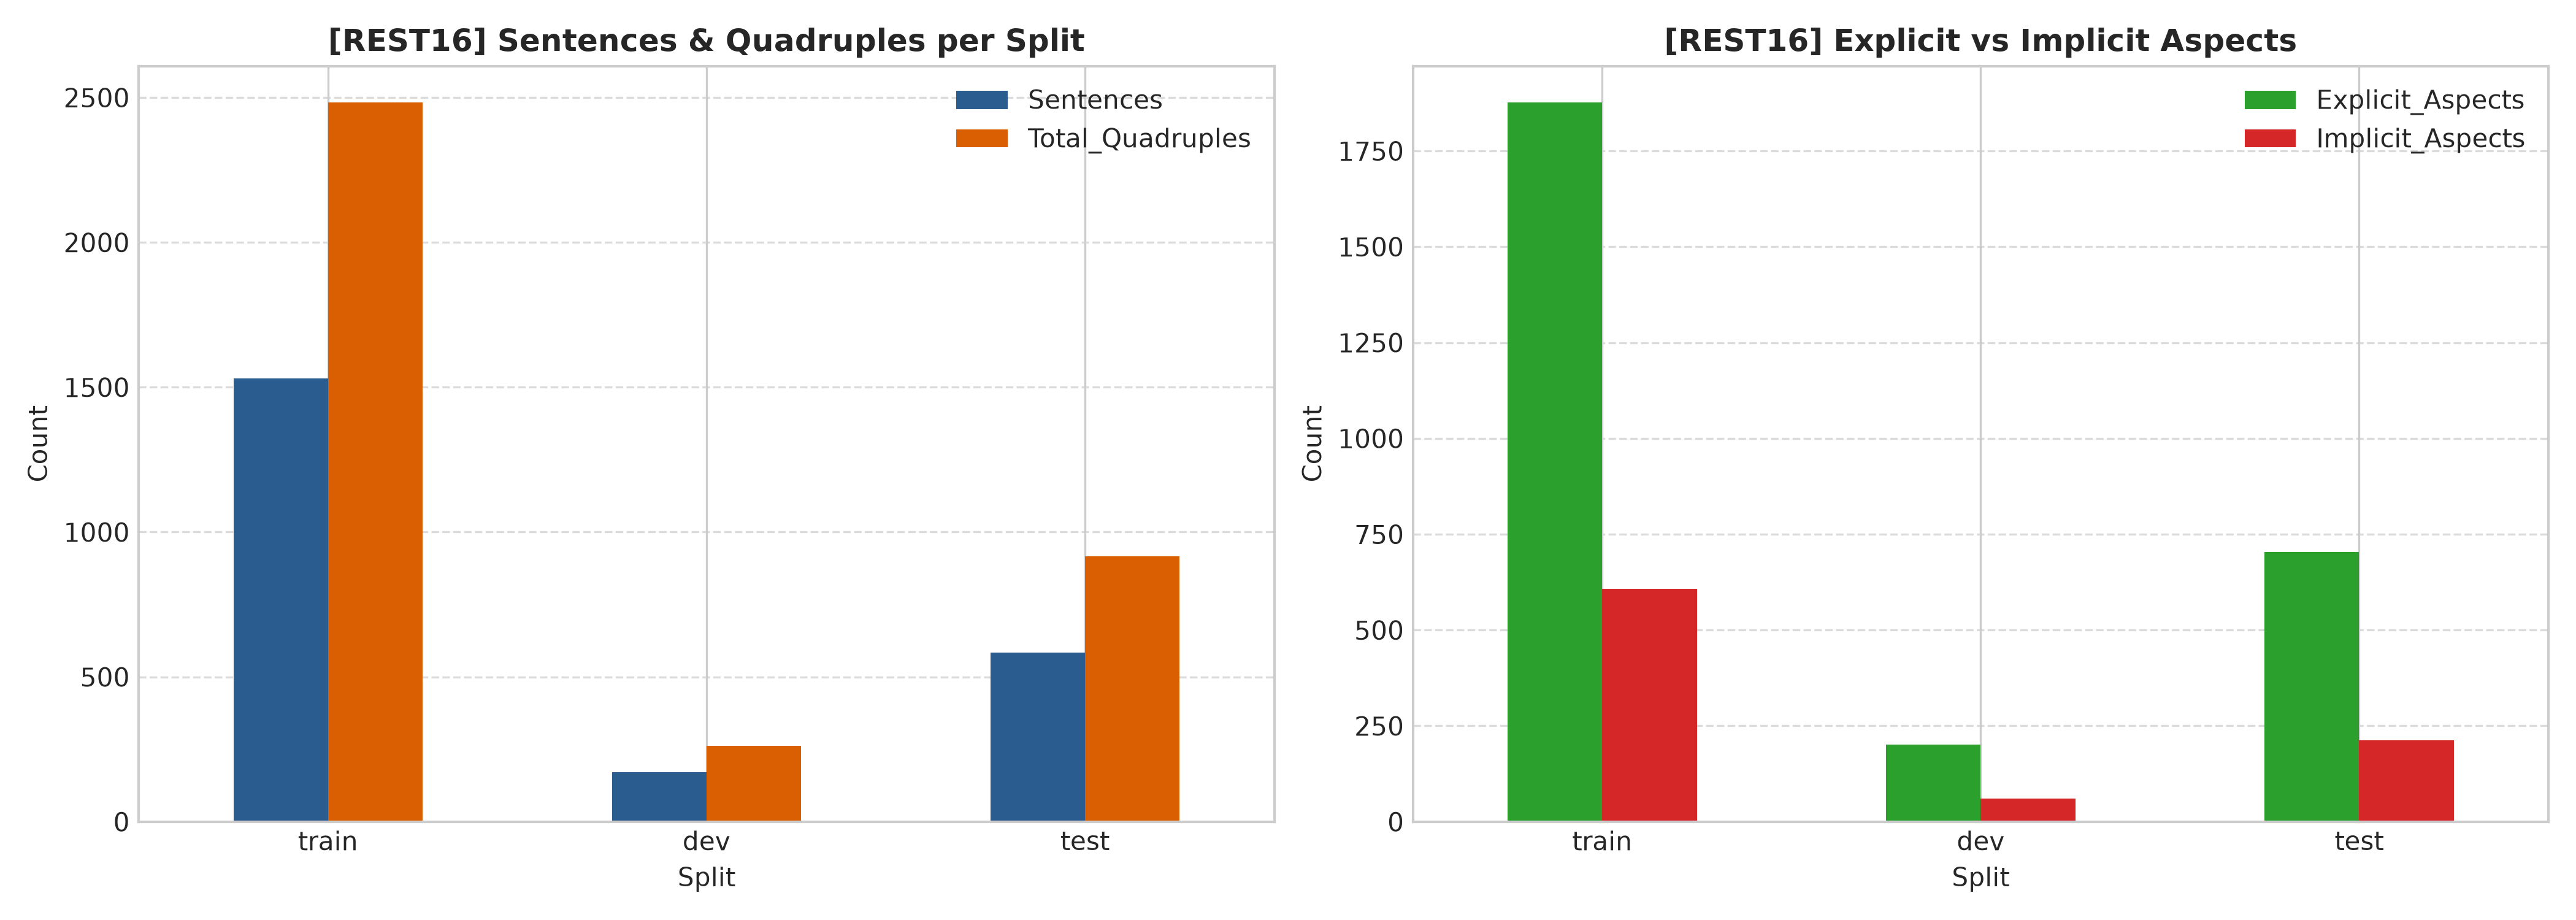

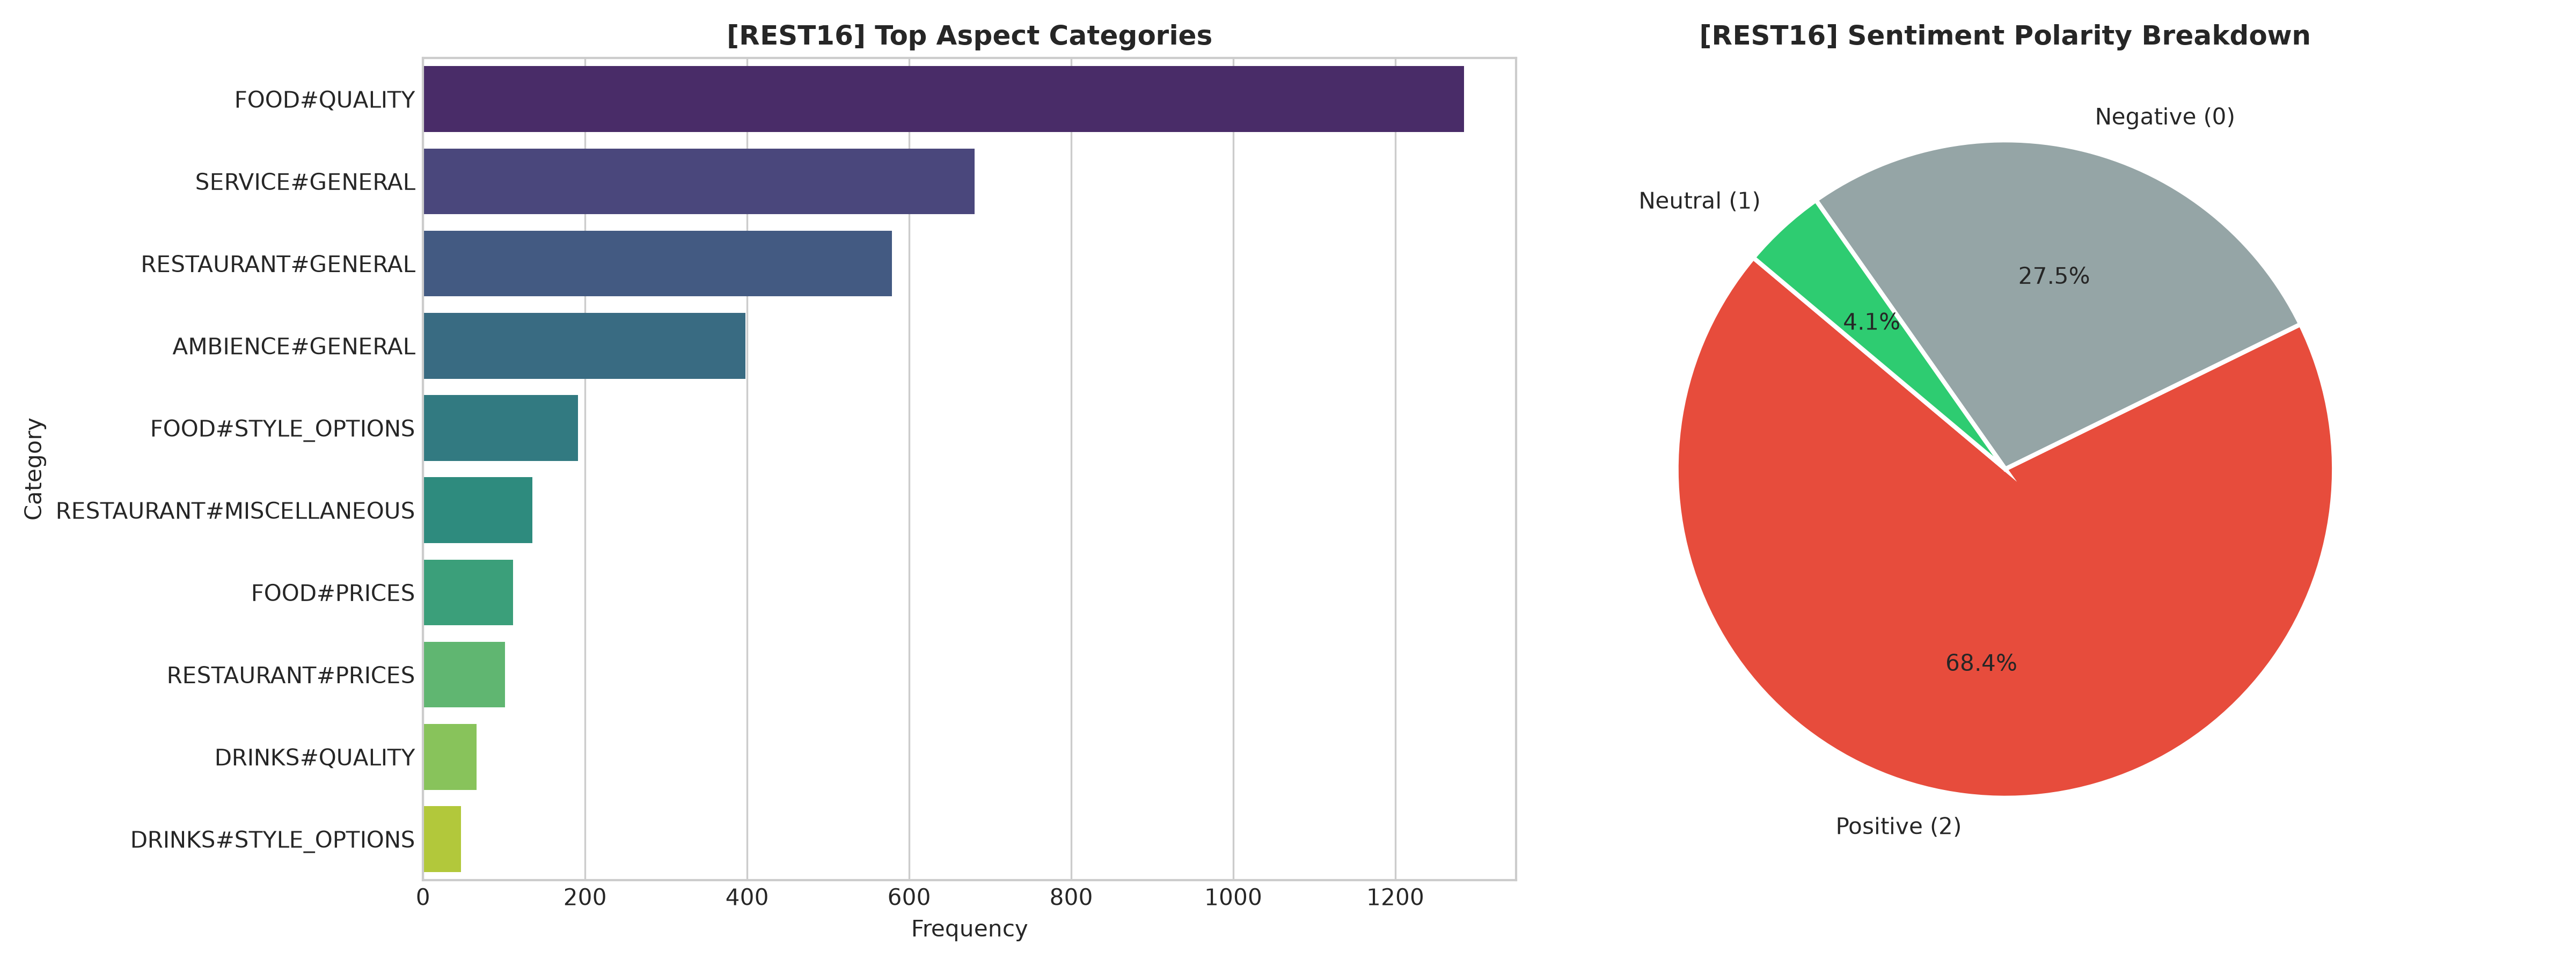

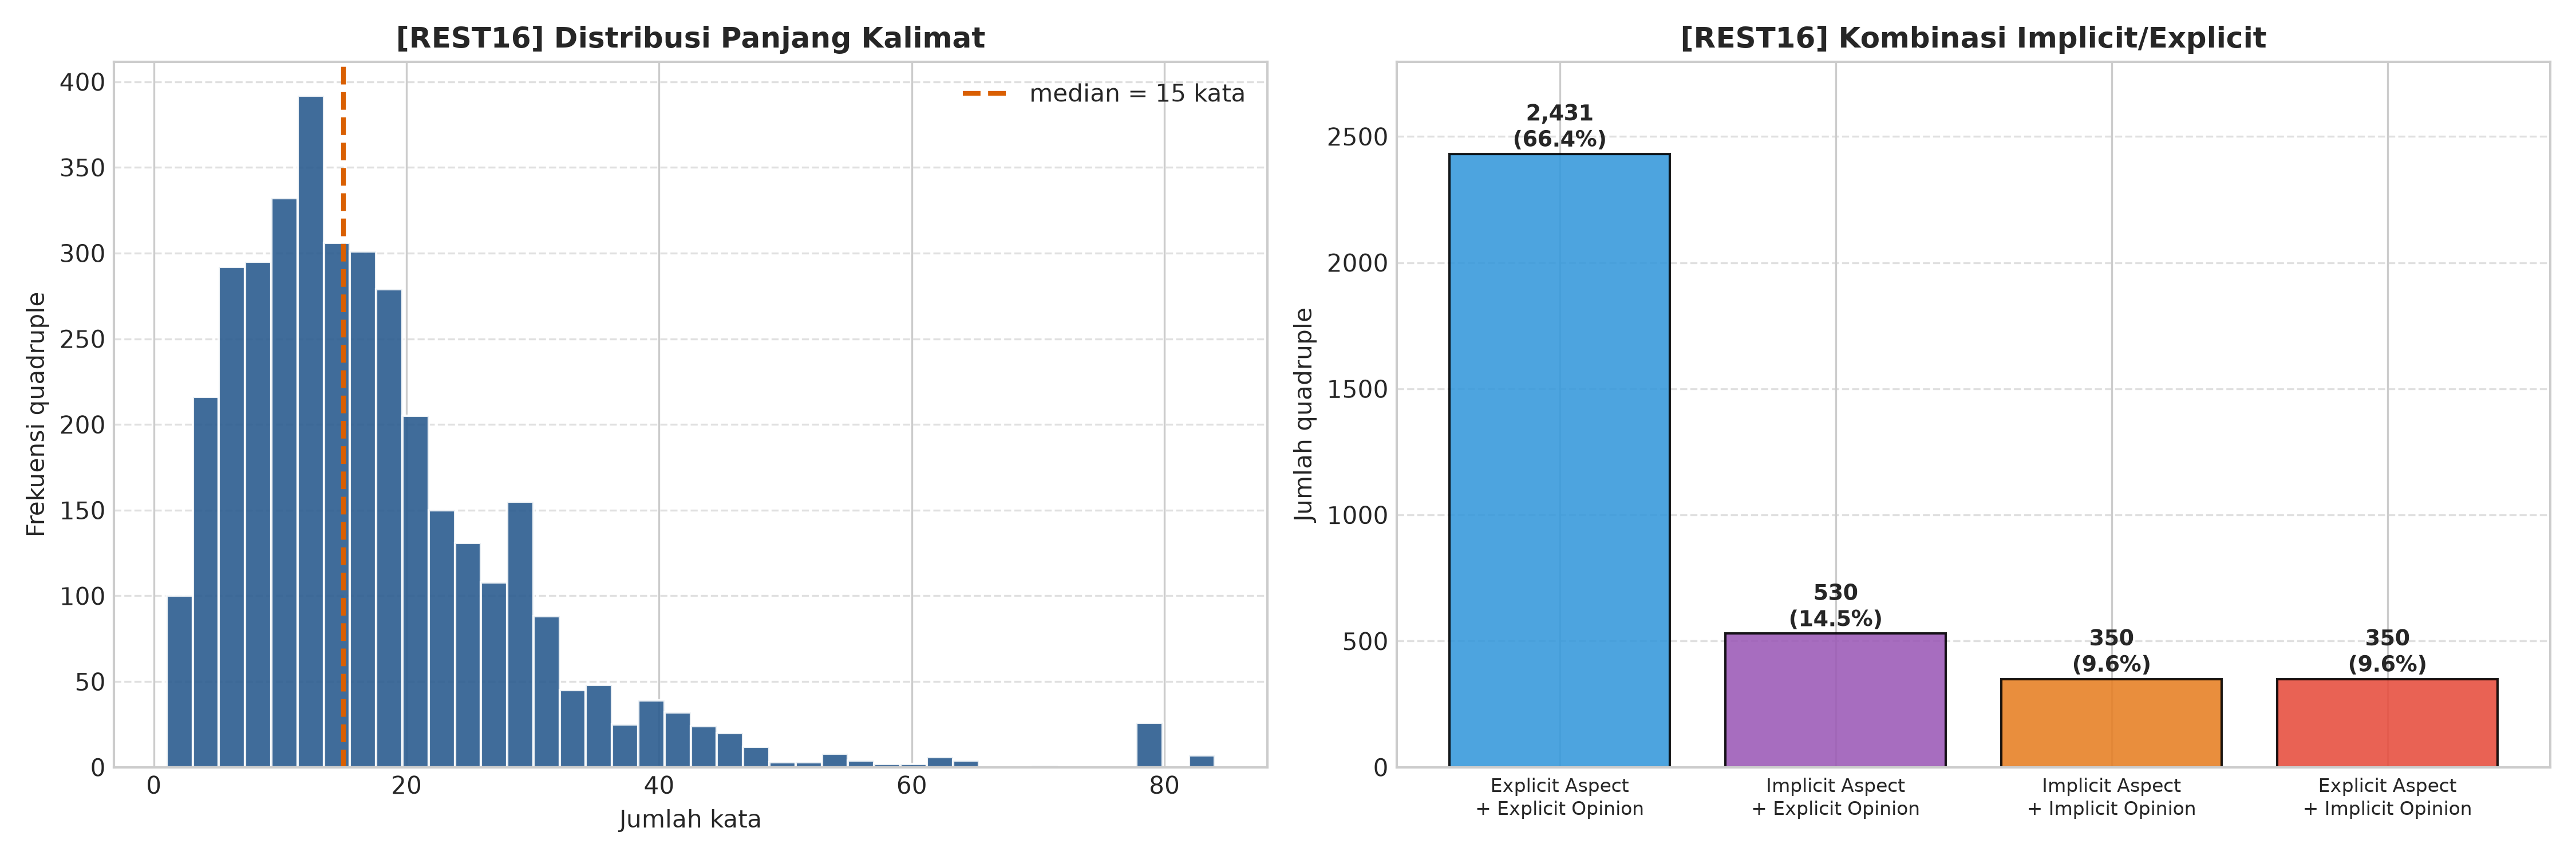

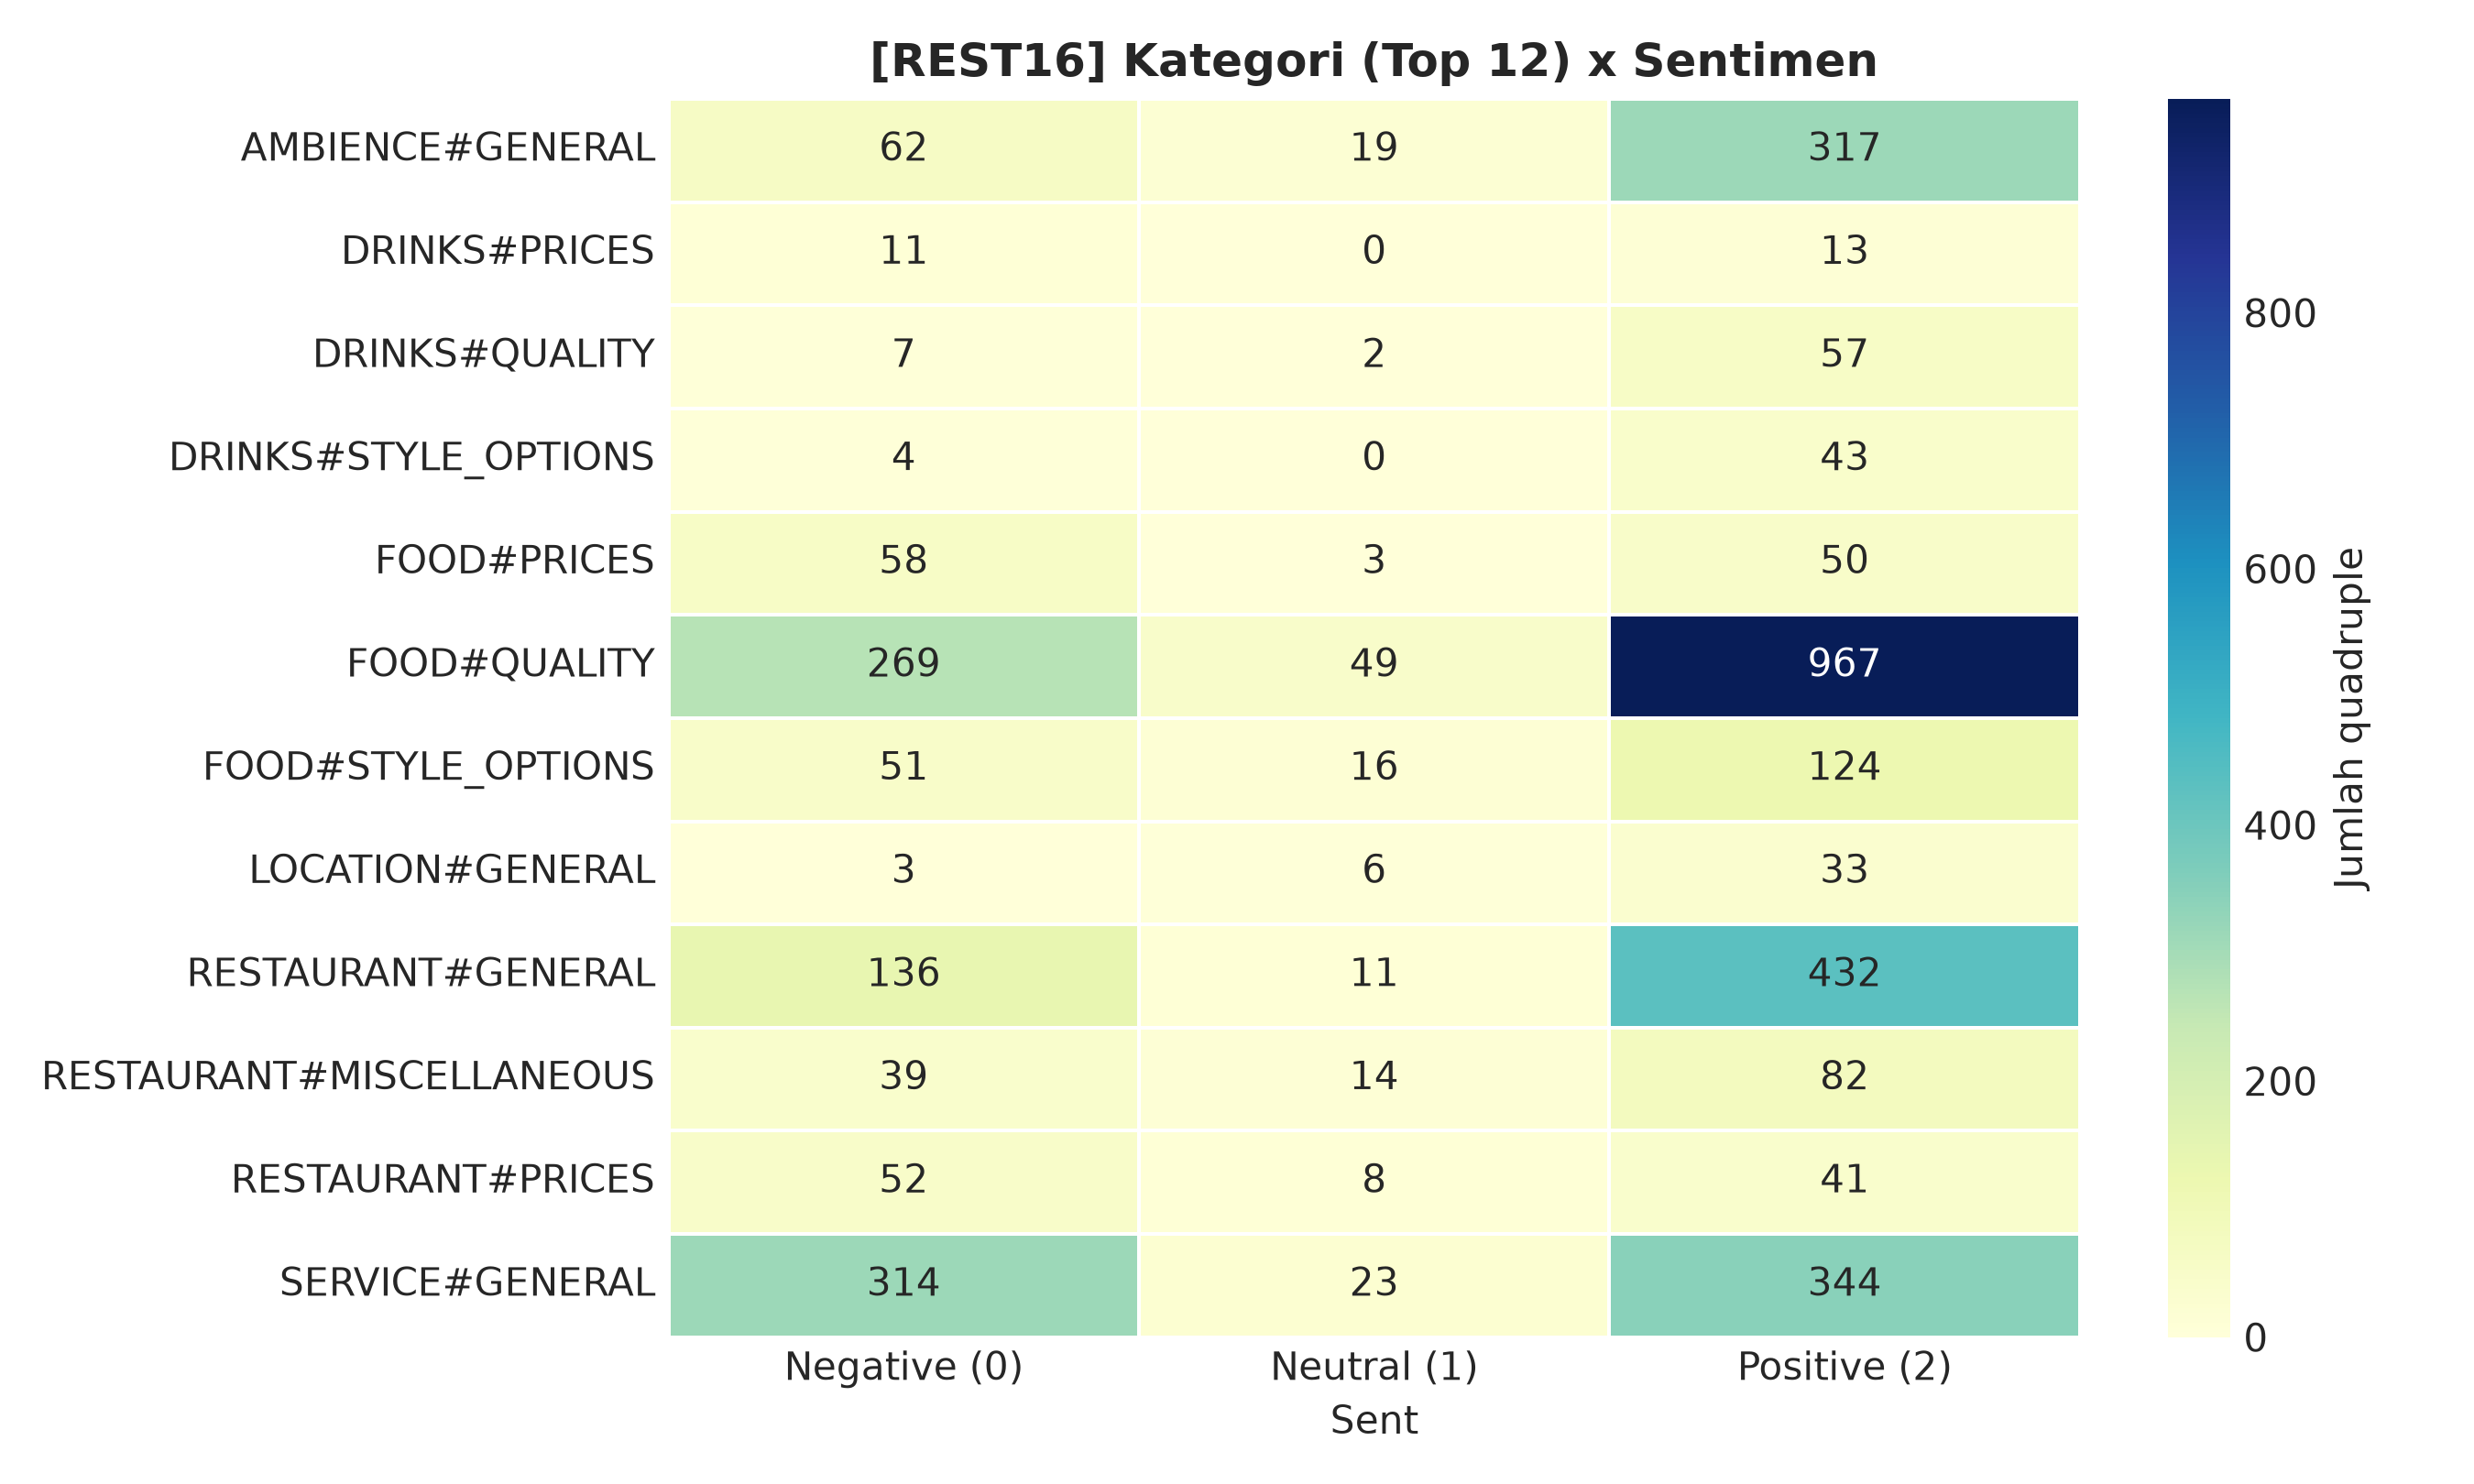

In [4]:
data_root = os.path.join(base_project_dir, "data")
df_stats, df_records = analyze_and_plot_eda(
    data_dir=data_root,
    domain=DOMAIN,
    output_plots_dir=plots_dir,
    output_csv_dir=csv_dir,
)

rep.section("2. Eksplorasi data")
if df_stats is None or df_stats.empty:
    print("[peringatan] Statistik EDA kosong: cek folder data/.")
    rep.text("Statistik EDA kosong; folder `data/` tidak ditemukan.")
else:
    export_step_table(df_stats, name="master_01_statistik_dataset", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Statistik Dataset {DOMAIN.upper()} per Split")
    rep.table(df_stats, caption="Statistik per split")

    n = len(df_records)
    df_ringkas = pd.DataFrame([{
        "Total_Quadruple": n,
        "Implicit_Aspect": int(df_records["Is_Implicit_Aspect"].sum()),
        "Implicit_Opinion": int(df_records["Is_Implicit_Opinion"].sum()),
        "Keduanya_Implicit": int((df_records["Is_Implicit_Aspect"] & df_records["Is_Implicit_Opinion"]).sum()),
        "Kategori_Unik": int(df_records["Category"].nunique()),
        "Panjang_Kalimat_Median": float(df_records["Text_Length"].median()),
    }])
    export_step_table(df_ringkas, name="master_02_ringkasan_eda", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Ringkasan EDA ({DOMAIN.upper()})")
    rep.table(df_ringkas, caption="Ringkasan EDA")

    from IPython.display import Image, display
    for fname, cap in [
        ("01_eda_dataset_distribution.png", "Komposisi dataset & explicit vs implicit"),
        ("02_eda_category_sentiment.png", "Kategori teratas & polaritas sentimen"),
        ("02b_eda_length_and_implicit_combo.png", "Panjang kalimat & kombinasi implicit"),
        ("02c_eda_category_sentiment_heatmap.png", "Heatmap kategori x sentimen"),
    ]:
        p = os.path.join(plots_dir, fname)
        if os.path.exists(p):
            display(Image(p))
            rep.image(p, cap)


In [5]:
import os

search_dir = "/content/drive/MyDrive/ACOS"
print(f"--- Mencari folder 'data' dan 'tokenized_data' di {search_dir} ---")
for root, dirs, files in os.walk(search_dir):
    if 'Restaurant-ACOS' in dirs or 'Laptop-ACOS' in dirs:
        print(f"✅ Ditemukan dataset di: {root}")
    if 'tokenized_data' in dirs:
        print(f"✅ Ditemukan tokenized_data di: {os.path.join(root, 'tokenized_data')}")
        print("Isi tokenized_data:", os.listdir(os.path.join(root, 'tokenized_data'))[:5])

--- Mencari folder 'data' dan 'tokenized_data' di /content/drive/MyDrive/ACOS ---


In [6]:
import os

print("--- Memperluas pencarian dataset ---")
search_dirs = ["/content", "/content/drive/MyDrive"]
for s_dir in search_dirs:
    if not os.path.exists(s_dir): continue
    print(f"\nMencari di: {s_dir}")
    for root, dirs, files in os.walk(s_dir):
        # Hindari pencarian terlalu dalam di folder yang tidak relevan
        if '.git' in dirs: dirs.remove('.git')
        if '.config' in dirs: dirs.remove('.config')

        if 'Restaurant-ACOS' in dirs or 'Laptop-ACOS' in dirs:
            print(f"✅ Ditemukan dataset di: {root}")
        if 'tokenized_data' in dirs:
            print(f"✅ Ditemukan tokenized_data di: {os.path.join(root, 'tokenized_data')}")

--- Memperluas pencarian dataset ---


## 5. Step 1: Aspect & Opinion Co-Extraction Training & Checkpointing
Trains `BertForQuadABSA` (BERT + CRF sequence tagger + implicit classification heads). Saves best model weights to `checkpoints/step1_best/`.

🚀 Training Step 1 Model (15 Epochs)...


/opt/venv/lib/python3.12/site-packages/torchcrf/__init__.py:249: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /__w/rockrel/rockrel/external-builds/pytorch/pytorch/aten/src/ATen/native/TensorCompare.cpp:622.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)
/shared-docker/ACOS/Extract-Classify-ACOS/bert_utils/optimization.py:275: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at /__w/rockrel/rockrel/external-builds/pytorch/pytorch/torch/csrc/utils/python_arg_parser.cpp:1870.)
  next_m.mul_(beta1).add_(1 - beta1, grad)



tp: 901.0. fp: 871.0. fn: 714.0.
Epoch 01 | Loss: 16.0837 | Test Micro-F1: 53.20%
🔥 Saving best Step 1 model to /shared-docker/ACOS/results/rest16_24092026_0849/checkpoints/step1_best...


tp: 1159.0. fp: 306.0. fn: 456.0.
Epoch 02 | Loss: 5.0927 | Test Micro-F1: 75.26%
🔥 Saving best Step 1 model to /shared-docker/ACOS/results/rest16_24092026_0849/checkpoints/step1_best...


tp: 1315.0. fp: 461.0. fn: 300.0.
Epoch 03 | Loss: 2.7054 | Test Micro-F1: 77.56%
🔥 Saving best Step 1 model to /shared-docker/ACOS/results/rest16_24092026_0849/checkpoints/step1_best...


...

tp: 1342.0. fp: 373.0. fn: 273.0.
Epoch 13 | Loss: 0.1025 | Test Micro-F1: 80.60%


tp: 1339.0. fp: 362.0. fn: 276.0.
Epoch 14 | Loss: 0.0883 | Test Micro-F1: 80.76%
🔥 Saving best Step 1 model to /shared-docker/ACOS/results/rest16_24092026_0849/checkpoints/step1_best...


tp: 1336.0. fp: 368.0. fn: 279.0.
Epoch 15 | Loss: 0.0803 | Test Micro-F1: 80.51%
📈 Saved training plot: /shared-docker/ACOS/results/rest16_24092026_0849/plots/03_step1_training_loss_f1_curve.png
=== Riwayat Training Step 1 (REST16) (15 baris) ===


,epoch,loss,precision,recall,micro-F1
0,1,16.083708,50.85,55.79,53.20
1,2,5.092734,79.11,71.76,75.26
2,3,2.705446,74.04,81.42,77.56
3,4,1.555525,79.75,80.25,80.00
4,5,1.072302,79.98,80.12,80.05
5,6,0.730020,78.53,82.23,80.34
6,7,0.542469,76.55,83.47,79.86
7,8,0.378975,77.75,82.23,79.93
8,9,0.280595,78.91,82.48,80.65
9,10,0.200786,77.58,81.61,79.54


[tabel] CSV: /shared-docker/ACOS/results/rest16_24092026_0849/csv/master_03_step1_riwayat.csv | MD: /shared-docker/ACOS/results/rest16_24092026_0849/md/master_03_step1_riwayat.md
Step 1 terbaik: epoch 14 (micro-F1 80.76%)


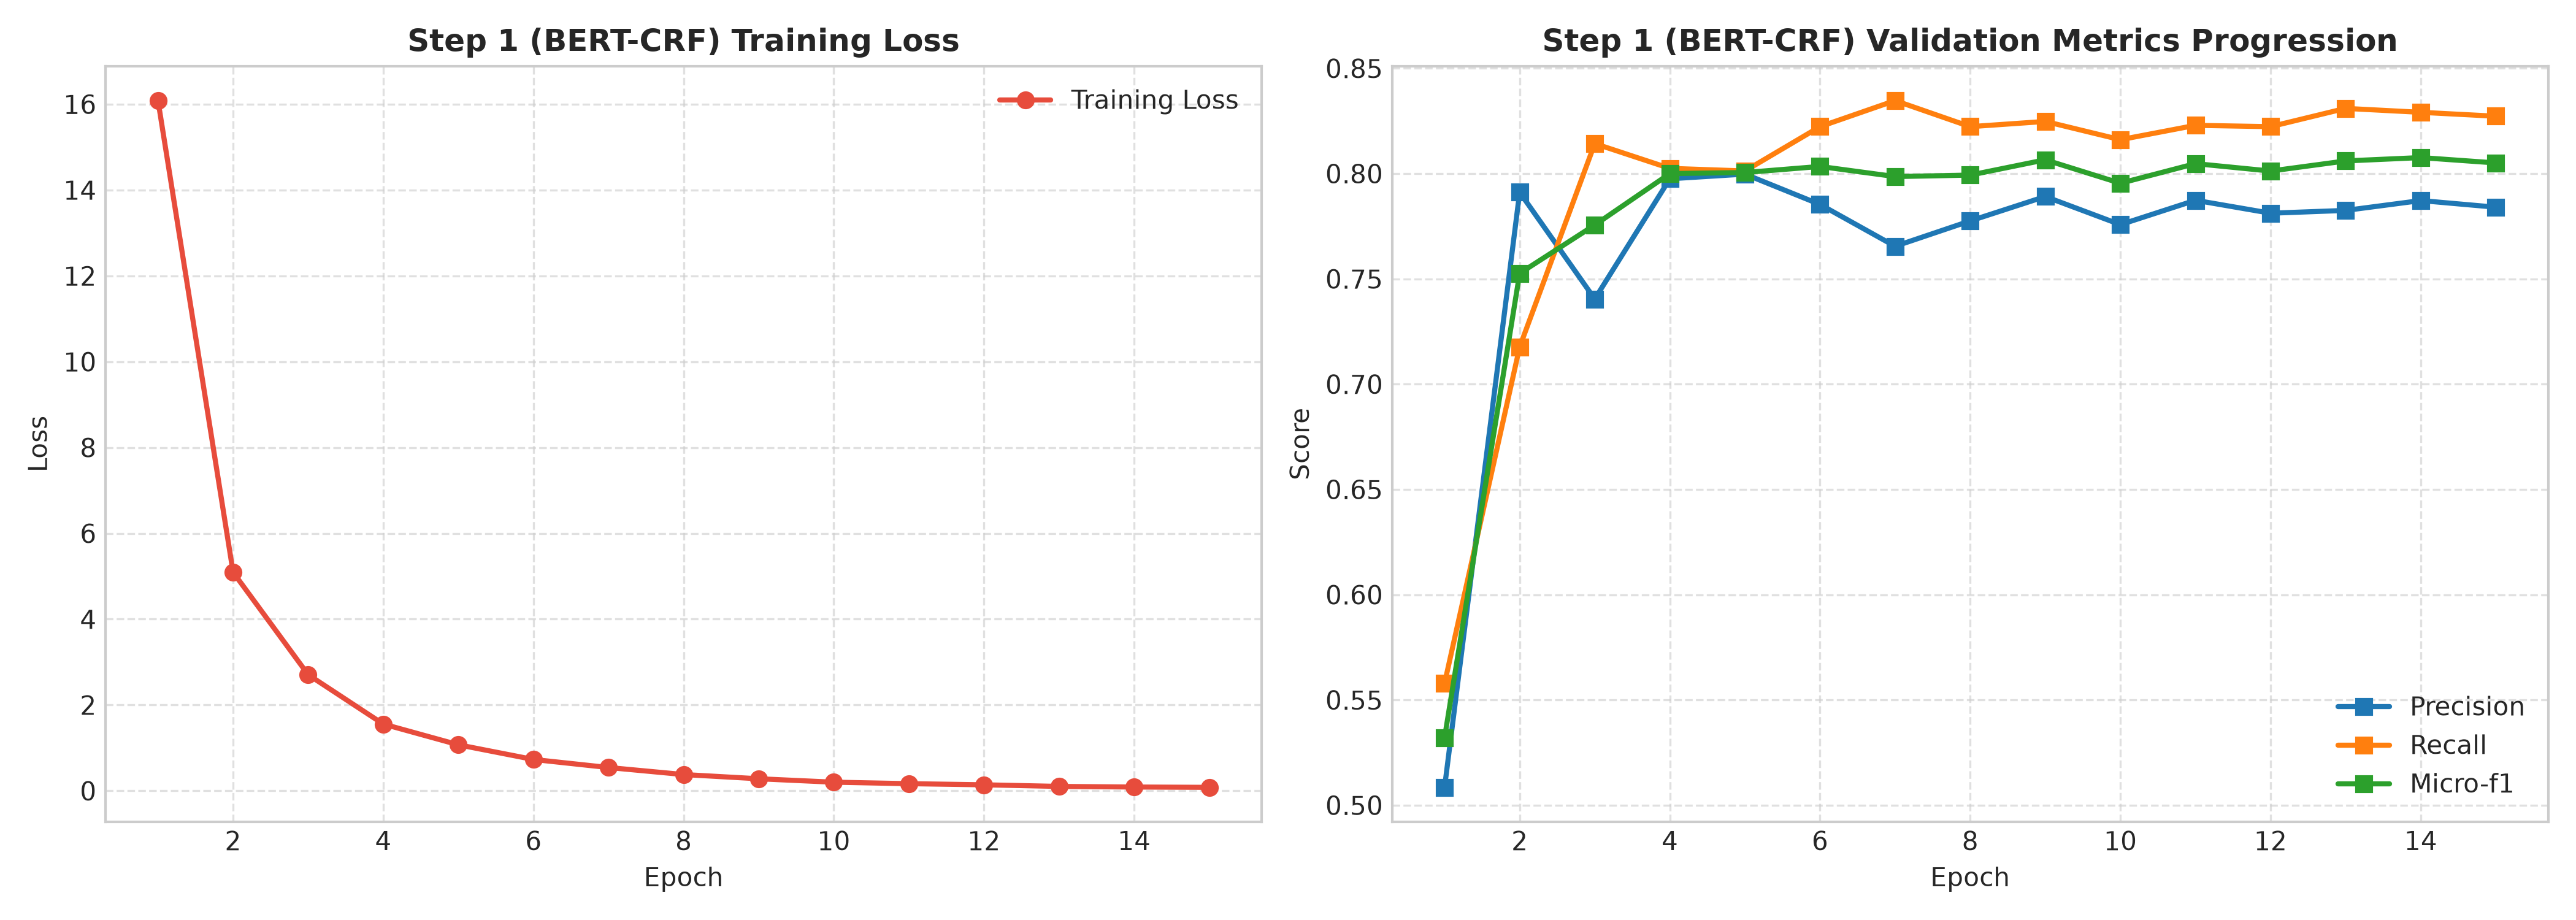

In [7]:
from modeling import BertForQuadABSA
from bert_utils.tokenization import BertTokenizer
from bert_utils.optimization import BertAdam
from run_classifier_dataset_utils import processors, output_modes
from eval_metrics import pred_eval
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from tqdm import tqdm

tokenizer = BertTokenizer.from_pretrained(bert_cache_dir, do_lower_case=True)
processor_step1 = processors["quad"]()
label_list_step1 = processor_step1.get_labels(DOMAIN)
num_labels_step1 = len(label_list_step1[1])
label_map_seq = {label: i for i, label in enumerate(label_list_step1[1])}

# Load Eval Data
eval_examples_1 = processor_step1.get_dev_examples(extract_dir, DOMAIN)
eval_features_1 = features_step1(eval_examples_1, label_list_step1, MAX_SEQ_LENGTH, tokenizer, output_modes["quad"], "quad")

ev_ids = torch.tensor([f.aspect_input_ids for f in eval_features_1], dtype=torch.long)
ev_mask = torch.tensor([f.aspect_input_mask for f in eval_features_1], dtype=torch.long)
ev_seg = torch.tensor([f.aspect_segment_ids for f in eval_features_1], dtype=torch.long)
ev_lbl = torch.tensor([f.aspect_ids for f in eval_features_1], dtype=torch.long)
ev_imp_a = torch.tensor([f.exist_imp_aspect for f in eval_features_1], dtype=torch.long)
ev_imp_o = torch.tensor([f.exist_imp_opinion for f in eval_features_1], dtype=torch.long)
ev_len = torch.tensor([f.tokens_len for f in eval_features_1], dtype=torch.long)
eval_data_1 = TensorDataset(ev_len, ev_ids, ev_mask, ev_lbl, ev_seg, ev_imp_a, ev_imp_o)
eval_loader_1 = DataLoader(eval_data_1, sampler=SequentialSampler(eval_data_1), batch_size=16)

# Load Gold
eval_gold_1 = []
with open(os.path.join(extract_dir, "tokenized_data", f"{DOMAIN}_test_quad_bert.tsv"), "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip().split("\t")
        cur_text = tokenizer.convert_tokens_to_ids(line[0].split(" "))
        aspect_labels = [label_map_seq['O'] for _ in range(MAX_SEQ_LENGTH)]
        cur_imp_a, cur_imp_o = 0, 0
        for quad in line[1:]:
            cur_aspect, cur_opinion = quad.split(' ')[0], quad.split(' ')[-1]
            a_st, a_ed = int(cur_aspect.split(',')[0]), int(cur_aspect.split(',')[1])
            if a_ed != -1:
                aspect_labels[a_st] = label_map_seq['B-A']
                for i in range(a_st+1, a_ed): aspect_labels[i] = label_map_seq['I-A']
            else: cur_imp_a = 1
            o_st, o_ed = int(cur_opinion.split(',')[0]), int(cur_opinion.split(',')[1])
            if o_ed != -1:
                aspect_labels[o_st] = label_map_seq['B-O']
                for i in range(o_st+1, o_ed): aspect_labels[i] = label_map_seq['I-O']
            else: cur_imp_o = 1
        eval_gold_1.append([cur_text, [aspect_labels, cur_imp_a, cur_imp_o]])
eval_gold_1 = [[e[0] for e in eval_gold_1], [item for e in eval_gold_1 for item in e[1]]]

# Instantiate Model
model_step1 = BertForQuadABSA.from_pretrained(bert_cache_dir, num_labels=num_labels_step1).to(device)

# Load Training Data
train_examples_1 = processor_step1.get_train_examples(extract_dir, DOMAIN)
train_features_1 = features_step1(train_examples_1, label_list_step1, MAX_SEQ_LENGTH, tokenizer, output_modes["quad"], "quad")
tr_data_1 = TensorDataset(
    torch.tensor([f.tokens_len for f in train_features_1], dtype=torch.long),
    torch.tensor([f.aspect_input_ids for f in train_features_1], dtype=torch.long),
    torch.tensor([f.aspect_input_mask for f in train_features_1], dtype=torch.long),
    torch.tensor([f.aspect_ids for f in train_features_1], dtype=torch.long),
    torch.tensor([f.aspect_segment_ids for f in train_features_1], dtype=torch.long),
    torch.tensor([f.exist_imp_aspect for f in train_features_1], dtype=torch.long),
    torch.tensor([f.exist_imp_opinion for f in train_features_1], dtype=torch.long)
)
train_loader_1 = DataLoader(tr_data_1, sampler=RandomSampler(tr_data_1), batch_size=STEP1_BATCH_SIZE)

# Optimizer
num_train_steps_1 = len(train_loader_1) * NUM_EPOCHS
param_opt = list(model_step1.named_parameters())
no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']
opt_grouped = [
    {'params': [p for n, p in param_opt if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n, p in param_opt if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
]
optimizer_1 = BertAdam(opt_grouped, lr=STEP1_LR, warmup=0.1, t_total=num_train_steps_1)

print(f"🚀 Training Step 1 Model ({NUM_EPOCHS} Epochs)...")
class ArgsH:
    def __init__(self):
        self.output_dir = session_dirs["logs"]
        self.max_seq_length = MAX_SEQ_LENGTH
args_h = ArgsH()
import logging
logger = logging.getLogger("Step1")

best_step1_f1 = 0.0
step1_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    model_step1.train()
    t_loss = 0.0
    for step, batch in enumerate(tqdm(train_loader_1, desc=f"Step 1 Epoch {epoch}/{NUM_EPOCHS}")):
        batch = tuple(t.to(device) for t in batch)
        _len, _ids, _mask, _lbls, _seg, _imp_a, _imp_o = batch
        out1 = model_step1(aspect_input_ids=_ids, aspect_labels=_lbls, aspect_token_type_ids=_seg, aspect_attention_mask=_mask, exist_imp_aspect=_imp_a, exist_imp_opinion=_imp_o)
        loss, _ = unpack_model_output(out1)
        loss.backward()
        optimizer_1.step()
        optimizer_1.zero_grad()
        t_loss += loss.item()

    avg_loss = t_loss / len(train_loader_1)
    model_step1.eval()
    val_res = pred_eval(epoch, args_h, logger, tokenizer, model_step1, eval_loader_1, eval_gold_1, label_list_step1, device, "quad", eval_type='test')
    val_f1 = val_res.get('micro-F1', 0.0)
    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Test Micro-F1: {val_f1*100:.2f}%")
    step1_history.append({"epoch": epoch, "loss": avg_loss, "precision": val_res.get('precision', 0.0), "recall": val_res.get('recall', 0.0), "micro-F1": val_f1})

    # Save Checkpoint
    if val_f1 > best_step1_f1:
        best_step1_f1 = val_f1
        print(f"🔥 Saving best Step 1 model to {session_dirs['step1_checkpoint']}...")
        torch.save(model_step1.state_dict(), os.path.join(session_dirs["step1_checkpoint"], "pytorch_model.bin"))
        model_step1.config.to_json_file(os.path.join(session_dirs["step1_checkpoint"], "config.json"))
        tokenizer.save_vocabulary(session_dirs["step1_checkpoint"])

# Export Step 1 Plot & CSV
plot_training_history(
    step1_history, task_name="Step 1 (BERT-CRF)",
    output_plot_path=os.path.join(session_dirs["plots"], "03_step1_training_loss_f1_curve.png"),
    output_csv_path=os.path.join(session_dirs["csv"], "step1_training_history.csv")
)

# --- Tabel & laporan step 1 ---
rep.section("3. Step 1: ekstraksi aspect & opinion")
df_s1 = pd.DataFrame(step1_history)
if not df_s1.empty:
    df_s1_pct = df_s1.copy()
    for c in ["precision", "recall", "micro-F1"]:
        if c in df_s1_pct.columns:
            df_s1_pct[c] = (df_s1_pct[c] * 100).round(2)
    export_step_table(df_s1_pct, name="master_03_step1_riwayat", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Riwayat Training Step 1 ({DOMAIN.upper()})",
                      notes="Metrik dihitung pada test set tiap epoch.",
                      max_rows_md=NUM_EPOCHS)
    rep.table(df_s1_pct, max_rows=NUM_EPOCHS, caption="Metrik step 1 per epoch")

    best1 = df_s1_pct.loc[df_s1_pct["micro-F1"].idxmax()]
    rep.kv({
        "epoch_terbaik": int(best1["epoch"]),
        "micro-F1_terbaik": f"{best1['micro-F1']:.2f}%",
        "checkpoint": session_dirs["step1_checkpoint"],
    })
    print(f"Step 1 terbaik: epoch {int(best1['epoch'])} (micro-F1 {best1['micro-F1']:.2f}%)")

_p1 = os.path.join(plots_dir, "03_step1_training_loss_f1_curve.png")
if os.path.exists(_p1):
    from IPython.display import Image, display
    display(Image(_p1))
    rep.image(_p1, "Kurva training step 1")


## 6. Candidate Pair Generation Bridge
Parses `pred4pipeline.txt` from Step 1 and forms candidate pairs $(a, o)$ for Step 2.

✅ Generated 1450 Candidate Pairs for Step 2. Saved to /shared-docker/ACOS/Extract-Classify-ACOS/tokenized_data/rest16_test_pair_1st.tsv.
=== Distribusi Tipe Pasangan Kandidat (REST16) (4 baris) ===


,Tipe_Pasangan,Jumlah,Persen
0,Explicit-Explicit,1105,76.21
1,Implicit-Explicit,147,10.14
2,Explicit-Implicit,109,7.52
3,Implicit-Implicit,89,6.14


[tabel] CSV: /shared-docker/ACOS/results/rest16_24092026_0849/csv/master_04_tipe_pasangan.csv | MD: /shared-docker/ACOS/results/rest16_24092026_0849/md/master_04_tipe_pasangan.md
=== Preview 20 Pasangan Kandidat (REST16) (20 baris) ===


,Text,Aspect_Span,Opinion_Span,Is_Implicit_Aspect,Is_Implicit_Opinion,Pair_Type
0,##m !,"-1,-1","0,1",True,False,Implicit-Explicit
1,really good su ##shi .,"3,5","2,3",False,False,Explicit-Explicit
2,the biggest portions but adequate .,"3,4","0,1",False,False,Explicit-Explicit
3,the biggest portions but adequate .,"3,4","5,6",False,False,Explicit-Explicit
4,tea cr ##eme br ##ule ##e is a must !,"0,7","9,10",False,False,Explicit-Explicit
5,has great su ##shi and even better service .,"3,5","2,3",False,False,Explicit-Explicit
6,has great su ##shi and even better service .,"3,5","7,8",False,False,Explicit-Explicit
7,has great su ##shi and even better service .,"8,9","2,3",False,False,Explicit-Explicit
8,has great su ##shi and even better service .,"8,9","7,8",False,False,Explicit-Explicit
9,entire staff was extremely acc ##omo ##dating ...,"2,3","5,8",False,False,Explicit-Explicit


[tabel] CSV: /shared-docker/ACOS/results/rest16_24092026_0849/csv/master_05_preview_pasangan.csv | MD: /shared-docker/ACOS/results/rest16_24092026_0849/md/master_05_preview_pasangan.md


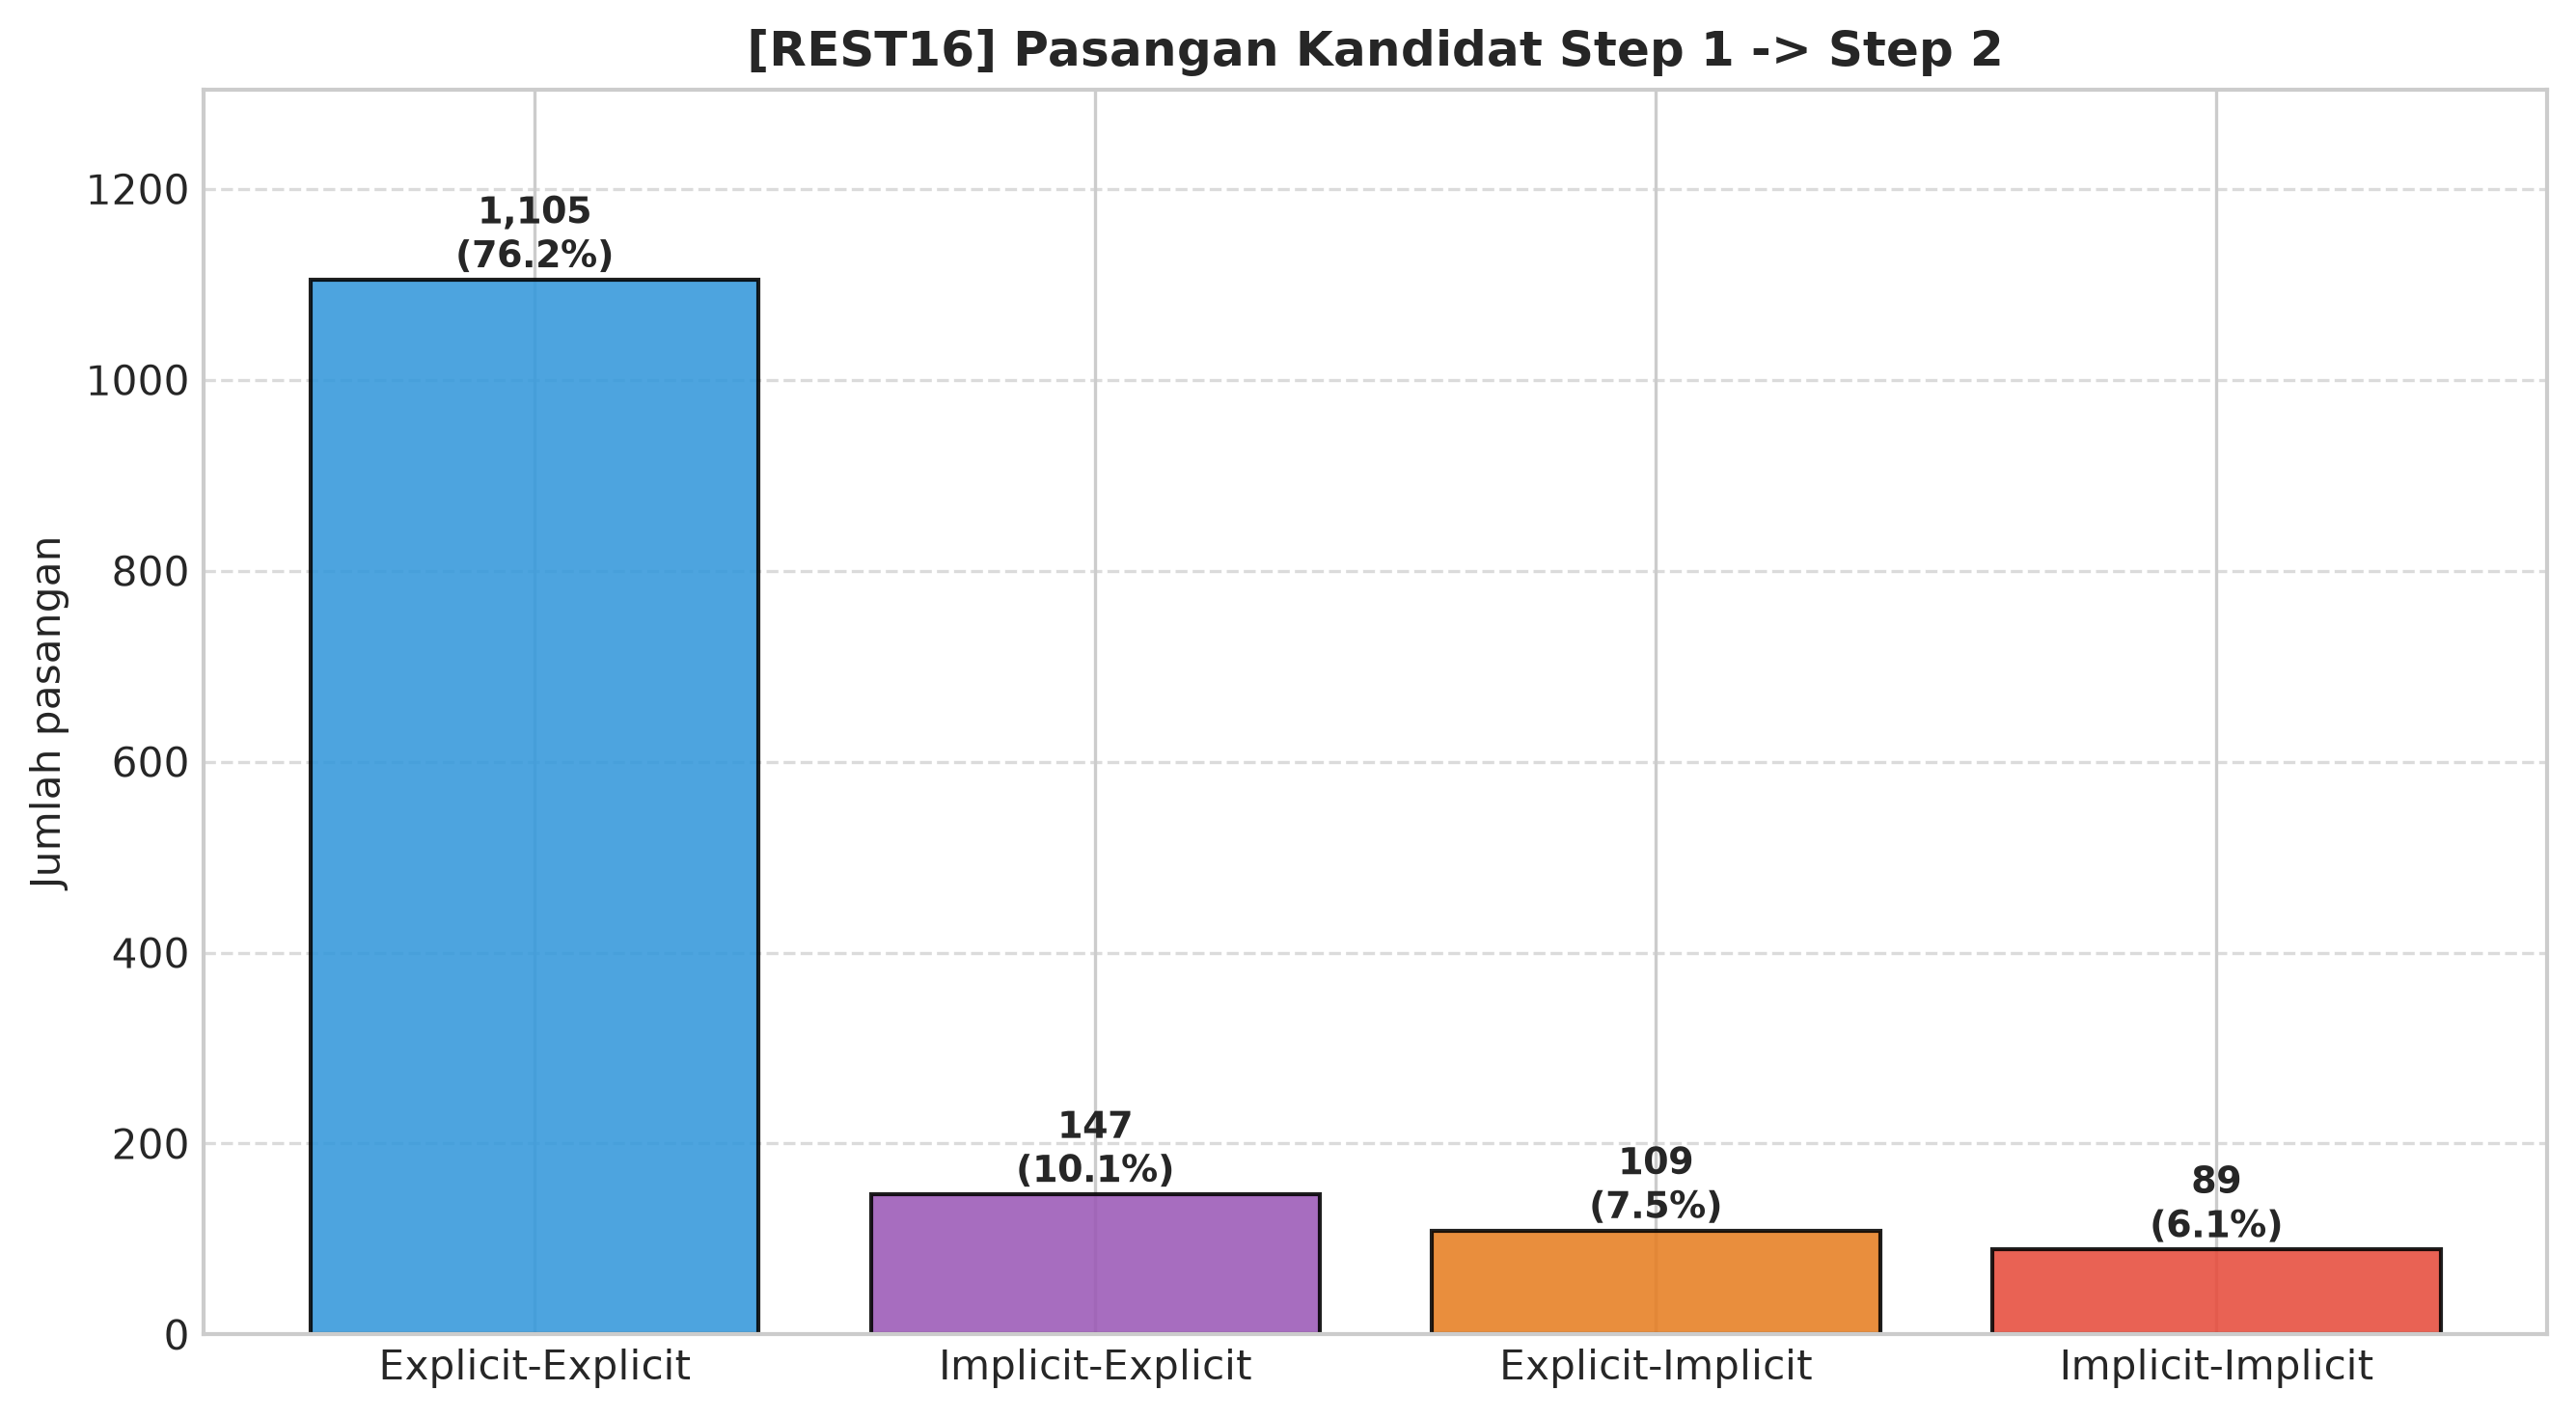

In [8]:
import codecs as cs
pred_file = os.path.join(session_dirs["logs"], "pred4pipeline.txt")
target_tokenized_tsv = os.path.join(extract_dir, "tokenized_data", f"{DOMAIN}_test_pair_1st.tsv")

with cs.open(pred_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()

pair_records = []
with cs.open(target_tokenized_tsv, 'w', encoding='utf-8') as wf:
    for idx, line in enumerate(lines):
        asp, opi = [], []
        parts = line.strip().split('\t')
        if len(parts) <= 1: continue
        text = parts[0]
        for ele in parts[1:]:
            if ele.startswith('a'): asp.append(ele[2:])
            else: opi.append(ele[2:])
        if not asp: asp.append('-1,-1')
        if not opi: opi.append('-1,-1')
        for pa in asp:
            for po in opi:
                wf.write(f"{text}####{pa} {po}\n")
                pair_records.append({"Text": text, "Aspect_Span": pa, "Opinion_Span": po})

df_pairs = pd.DataFrame(pair_records)
df_pairs.to_csv(os.path.join(session_dirs["csv"], "candidate_pairs_summary.csv"), index=False)
print(f"✅ Generated {len(df_pairs)} Candidate Pairs for Step 2. Saved to {target_tokenized_tsv}.")

# --- Tabel & laporan jembatan step 1 -> step 2 ---
rep.section("4. Jembatan: pasangan kandidat")
if df_pairs.empty:
    rep.text("Tidak ada pasangan kandidat yang terbentuk.")
else:
    df_pairs["Is_Implicit_Aspect"] = df_pairs["Aspect_Span"] == "-1,-1"
    df_pairs["Is_Implicit_Opinion"] = df_pairs["Opinion_Span"] == "-1,-1"
    df_pairs["Pair_Type"] = (
        df_pairs["Is_Implicit_Aspect"].map({True: "Implicit", False: "Explicit"}) + "-"
        + df_pairs["Is_Implicit_Opinion"].map({True: "Implicit", False: "Explicit"})
    )
    n_pair = len(df_pairs)
    df_tipe = df_pairs["Pair_Type"].value_counts().rename_axis("Tipe_Pasangan").reset_index(name="Jumlah")
    df_tipe["Persen"] = (df_tipe["Jumlah"] / n_pair * 100).round(2)

    export_step_table(df_tipe, name="master_04_tipe_pasangan", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Distribusi Tipe Pasangan Kandidat ({DOMAIN.upper()})",
                      notes=f"Total {n_pair} pasangan dari cross-product aspect x opinion.")
    rep.table(df_tipe, caption="Tipe pasangan")

    export_step_table(df_pairs.head(20), name="master_05_preview_pasangan",
                      csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Preview 20 Pasangan Kandidat ({DOMAIN.upper()})", max_rows_md=20)

    plt.figure(figsize=(9, 5))
    _w = ["#3498db", "#9b59b6", "#e67e22", "#e74c3c"][:len(df_tipe)]
    _b = plt.bar(df_tipe["Tipe_Pasangan"], df_tipe["Jumlah"], color=_w,
                 edgecolor="black", alpha=0.88)
    for b, v in zip(_b, df_tipe["Jumlah"]):
        plt.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v/n_pair*100:.1f}%)",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
    plt.title(f"[{DOMAIN.upper()}] Pasangan Kandidat Step 1 -> Step 2", fontsize=12, fontweight="bold")
    plt.ylabel("Jumlah pasangan")
    plt.margins(y=0.18)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    _pp = os.path.join(plots_dir, "04_candidate_pairs_distribution.png")
    plt.savefig(_pp, dpi=300)
    plt.show()
    plt.close()
    rep.image(_pp, "Distribusi tipe pasangan kandidat")


## 7. Step 2: Category & Sentiment Classification Training & Checkpointing
Trains `CategorySentiClassification` and saves the best model checkpoint to `checkpoints/step2_best/`.

[data] Evaluasi memakai pasangan prediksi step 1: /shared-docker/ACOS/Extract-Classify-ACOS/tokenized_data/rest16_test_pair_1st.tsv
🚀 Training Step 2 Model (15 Epochs)...


Quad num: 301
tp: 0.0. fp: 301.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 70.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 70.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 144.0.
1 :  {'precision': 0, 'recall': 

Quad num: 741
tp: 0.0. fp: 739.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 367.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 357.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 144.0.
1 :  {'precision': 0, 'recall'

Quad num: 971
tp: 0.0. fp: 968.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 494.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 477.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 144.0.
1 :  {'precision': 0, 'recall'

Quad num: 971
tp: 0.0. fp: 968.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 486.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 455.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 144.0.
1 :  {'precision': 0, 'recall'

...

Quad num: 1072
tp: 0.0. fp: 1069.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 548.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 503.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 144.0.
1 :  {'precision': 0, 'recal

Quad num: 1076
tp: 0.0. fp: 1073.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 553.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 506.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 144.0.
1 :  {'precision': 0, 'recal

Quad num: 1074
tp: 0.0. fp: 1071.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 547.0. fn: 715.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 503.0. fn: 623.0.
4 :  {'precision': 0.0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 144.0.
1 :  {'precision': 0, 'recal

,epoch,loss,precision,recall,micro-F1
0,1,0.178458,0.0,0.0,0
1,2,0.074358,0.0,0.0,0
2,3,0.048011,0.0,0.0,0
3,4,0.032707,0.0,0.0,0
4,5,0.021453,0.0,0.0,0
5,6,0.015851,0.0,0.0,0
6,7,0.011809,0.0,0.0,0
7,8,0.009011,0.0,0.0,0
8,9,0.007015,0.0,0.0,0
9,10,0.005774,0.0,0.0,0


[tabel] CSV: /shared-docker/ACOS/results/rest16_24092026_0849/csv/master_06_step2_riwayat.csv | MD: /shared-docker/ACOS/results/rest16_24092026_0849/md/master_06_step2_riwayat.md
Step 2 terbaik: epoch 1 (micro-F1 0.00%)


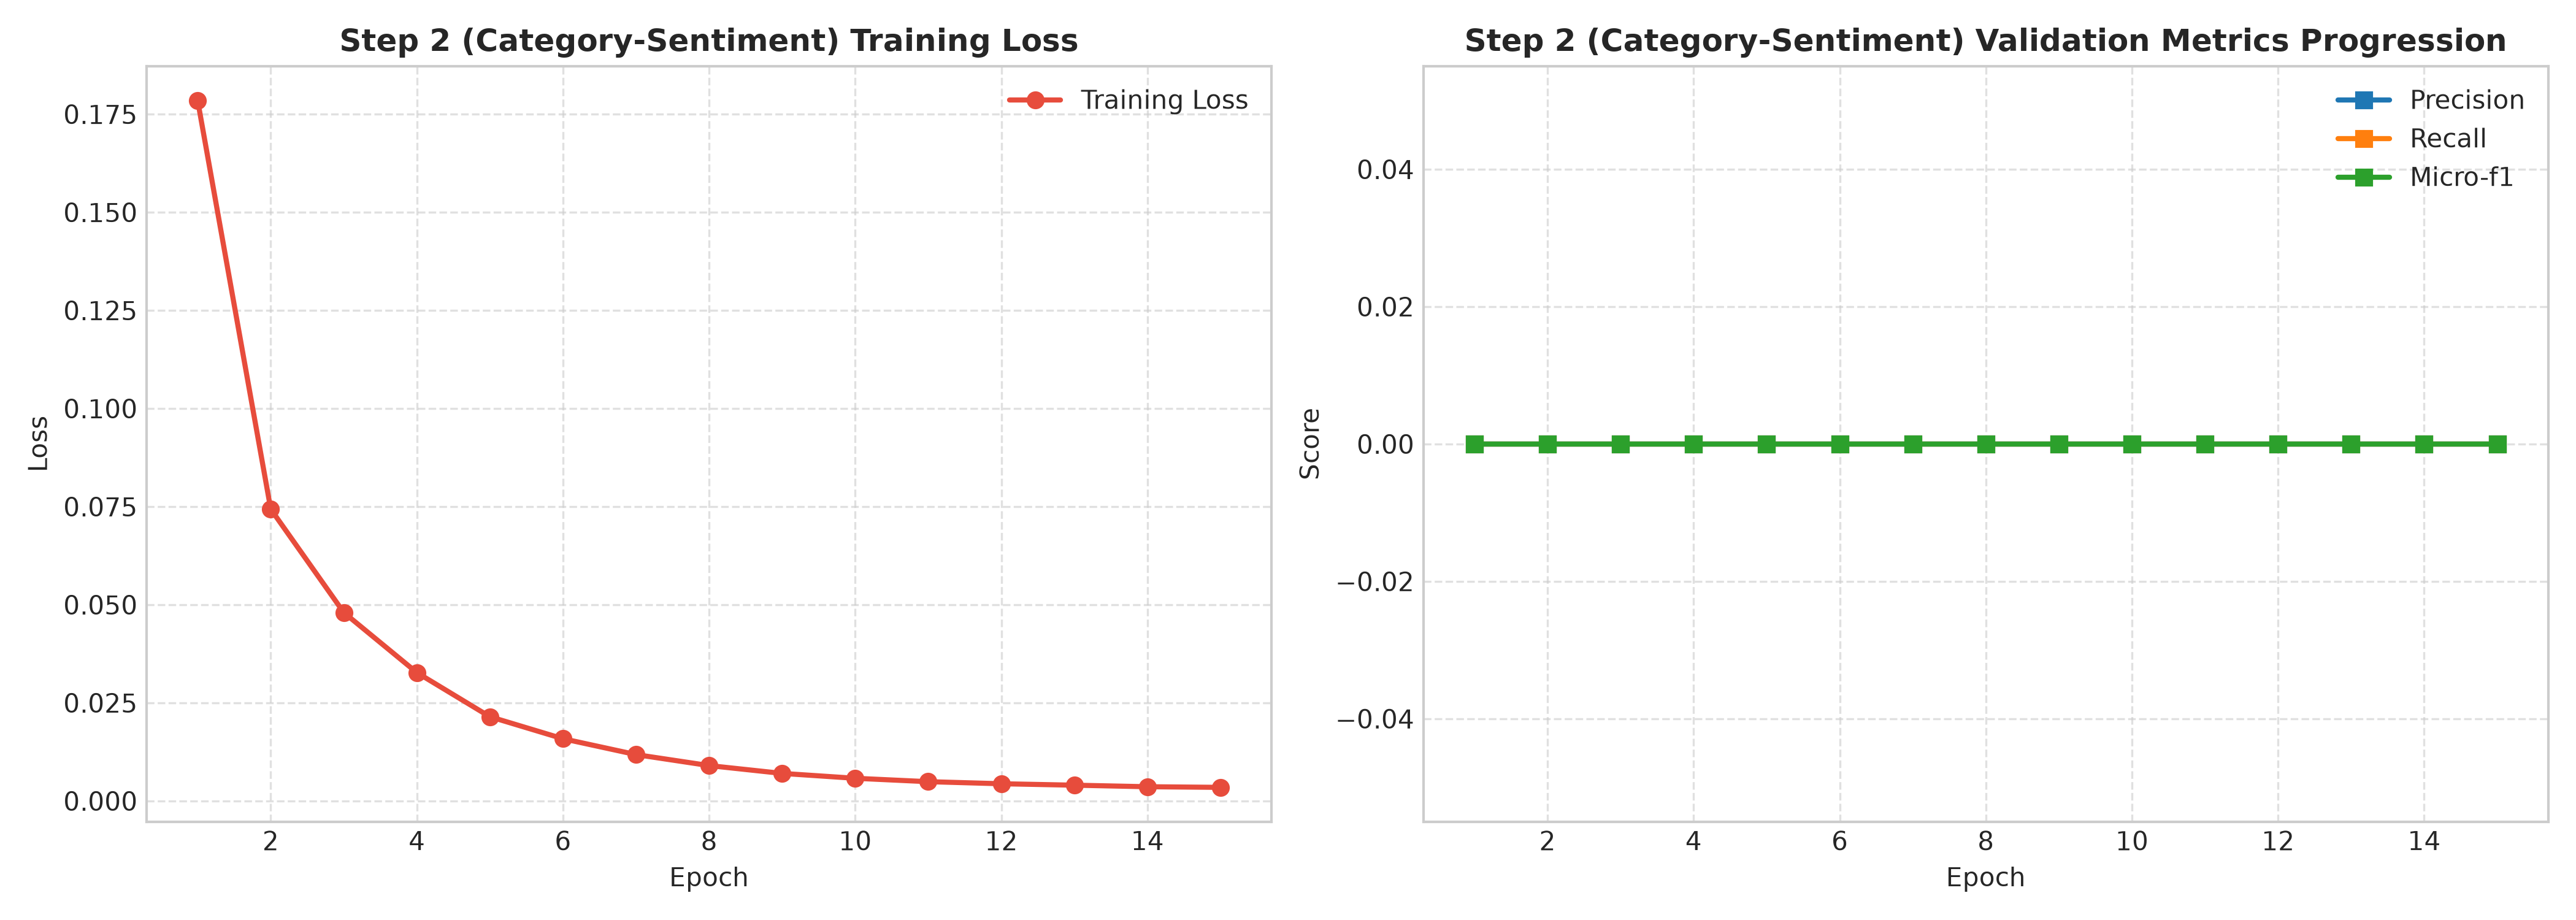

In [9]:
from modeling import CategorySentiClassification
from dataset_utils import read_pair_gold
from eval_metrics import pair_eval

processor_step2 = processors["categorysenti"]()
label_list_step2 = processor_step2.get_labels(DOMAIN)
num_labels_step2 = len(label_list_step2[0])

# Load Step 2 Eval Features from Step 1 Candidate Pairs
# Kandidat evaluasi: pasangan hasil prediksi step 1 bila ada, jika tidak gold pair.
tokenized_dir = os.path.join(extract_dir, "tokenized_data")
eval_pair_file, pakai_1st = resolve_eval_pair_file(tokenized_dir, DOMAIN, prefer_1st=True)
eval_examples_2 = pair_examples_from_file(processor_step2, eval_pair_file, set_type="test")
eval_features_2 = features_step2(eval_examples_2, label_list_step2, MAX_SEQ_LENGTH, tokenizer, output_modes["categorysenti"])

ev2_data = TensorDataset(
    torch.tensor([f.tokens_len for f in eval_features_2], dtype=torch.long),
    torch.tensor([f.aspect_input_ids for f in eval_features_2], dtype=torch.long),
    torch.tensor([f.aspect_input_mask for f in eval_features_2], dtype=torch.long),
    torch.tensor([f.aspect_segment_ids for f in eval_features_2], dtype=torch.long),
    torch.tensor([f.candidate_aspect for f in eval_features_2], dtype=torch.long),
    torch.tensor([f.candidate_opinion for f in eval_features_2], dtype=torch.long),
    torch.tensor([f.label_id for f in eval_features_2], dtype=torch.float)
)
eval_loader_2 = DataLoader(ev2_data, sampler=SequentialSampler(ev2_data), batch_size=16)

# Load Gold
class ArgsProxy:
    def __init__(self): self.bert_model = bert_cache_dir; self.do_lower_case = True
with open(os.path.join(extract_dir, "tokenized_data", f"{DOMAIN}_test_pair.tsv"), "r", encoding="utf-8") as f:
    eval_gold_2 = read_pair_gold(f.readlines(), ArgsProxy())

# Instantiate Model
model_step2 = CategorySentiClassification.from_pretrained(bert_cache_dir, num_labels=num_labels_step2).to(device)

# Load Train Data
train_examples_2 = processor_step2.get_train_examples(extract_dir, DOMAIN)
train_features_2 = features_step2(train_examples_2, label_list_step2, MAX_SEQ_LENGTH, tokenizer, output_modes["categorysenti"])
tr2_data = TensorDataset(
    torch.tensor([f.tokens_len for f in train_features_2], dtype=torch.long),
    torch.tensor([f.aspect_input_ids for f in train_features_2], dtype=torch.long),
    torch.tensor([f.aspect_input_mask for f in train_features_2], dtype=torch.long),
    torch.tensor([f.aspect_segment_ids for f in train_features_2], dtype=torch.long),
    torch.tensor([f.candidate_aspect for f in train_features_2], dtype=torch.long),
    torch.tensor([f.candidate_opinion for f in train_features_2], dtype=torch.long),
    torch.tensor([f.label_id for f in train_features_2], dtype=torch.float)
)
train_loader_2 = DataLoader(tr2_data, sampler=RandomSampler(tr2_data), batch_size=STEP2_BATCH_SIZE)

# Optimizer
num_train_steps_2 = len(train_loader_2) * NUM_EPOCHS
param_opt2 = list(model_step2.named_parameters())
opt_grouped2 = [
    {'params': [p for n, p in param_opt2 if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n, p in param_opt2 if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
]
optimizer_2 = BertAdam(opt_grouped2, lr=STEP2_LR, warmup=0.1, t_total=num_train_steps_2)

print(f"🚀 Training Step 2 Model ({NUM_EPOCHS} Epochs)...")
logger2 = logging.getLogger("Step2")
best_step2_f1 = 0.0
step2_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    model_step2.train()
    t_loss = 0.0
    for step, batch in enumerate(tqdm(train_loader_2, desc=f"Step 2 Epoch {epoch}/{NUM_EPOCHS}")):
        batch = tuple(t.to(device) for t in batch)
        _len, _ids, _mask, _seg, _cand_a, _cand_o, _lbls = batch
        out2 = model_step2(tokenizer, epoch, aspect_input_ids=_ids, aspect_token_type_ids=_seg, aspect_attention_mask=_mask, candidate_aspect=_cand_a, candidate_opinion=_cand_o, label_id=_lbls)
        loss, _ = unpack_model_output(out2)
        loss.backward()
        optimizer_2.step()
        optimizer_2.zero_grad()
        t_loss += loss.item()

    avg_loss = t_loss / len(train_loader_2)
    model_step2.eval()
    val_res = pair_eval(epoch, args_h, logger2, tokenizer, model_step2, eval_loader_2, eval_gold_2, label_list_step2, device, "categorysenti", eval_type='test')
    val_f1 = val_res.get('micro-F1', 0.0)
    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Test Micro-F1: {val_f1*100:.2f}%")
    step2_history.append({"epoch": epoch, "loss": avg_loss, "precision": val_res.get('precision', 0.0), "recall": val_res.get('recall', 0.0), "micro-F1": val_f1})

    if val_f1 > best_step2_f1:
        best_step2_f1 = val_f1
        print(f"🔥 Saving best Step 2 model to {session_dirs['step2_checkpoint']}...")
        torch.save(model_step2.state_dict(), os.path.join(session_dirs["step2_checkpoint"], "pytorch_model.bin"))
        model_step2.config.to_json_file(os.path.join(session_dirs["step2_checkpoint"], "config.json"))
        tokenizer.save_vocabulary(session_dirs["step2_checkpoint"])

# Export Step 2 Plot & CSV
plot_training_history(
    step2_history, task_name="Step 2 (Category-Sentiment)",
    output_plot_path=os.path.join(session_dirs["plots"], "04_step2_training_loss_f1_curve.png"),
    output_csv_path=os.path.join(session_dirs["csv"], "step2_training_history.csv")
)

# --- Tabel & laporan step 2 ---
rep.section("5. Step 2: klasifikasi category & sentiment")
df_s2 = pd.DataFrame(step2_history)
if not df_s2.empty:
    df_s2_pct = df_s2.copy()
    for c in ["precision", "recall", "micro-F1"]:
        if c in df_s2_pct.columns:
            df_s2_pct[c] = (df_s2_pct[c] * 100).round(2)
    export_step_table(df_s2_pct, name="master_06_step2_riwayat", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Riwayat Training Step 2 ({DOMAIN.upper()})",
                      notes=("Metrik pada level quadruple lengkap. Sumber kandidat: "
                             f"{'prediksi step 1' if pakai_1st else 'gold pair'}."),
                      max_rows_md=NUM_EPOCHS)
    rep.table(df_s2_pct, max_rows=NUM_EPOCHS, caption="Metrik step 2 per epoch")

    best2 = df_s2_pct.loc[df_s2_pct["micro-F1"].idxmax()]
    rep.kv({
        "epoch_terbaik": int(best2["epoch"]),
        "micro-F1_terbaik": f"{best2['micro-F1']:.2f}%",
        "checkpoint": session_dirs["step2_checkpoint"],
    })
    print(f"Step 2 terbaik: epoch {int(best2['epoch'])} (micro-F1 {best2['micro-F1']:.2f}%)")

_p2 = os.path.join(plots_dir, "04_step2_training_loss_f1_curve.png")
if os.path.exists(_p2):
    from IPython.display import Image, display
    display(Image(_p2))
    rep.image(_p2, "Kurva training step 2")


## 8. Evaluasi Akhir & Tabel Metrik

Metrik diambil dari evaluasi checkpoint terbaik pada sesi ini.


In [10]:
# Evaluasi final memakai checkpoint step 2 terbaik. Metrik 15 sub-task hanya
# ditulis ke logger oleh pair_eval, sehingga ditangkap dengan SubtaskMetricCapture
# agar angka yang dilaporkan berasal dari evaluasi nyata sesi ini.
model_step2_best = CategorySentiClassification.from_pretrained(
    session_dirs["step2_checkpoint"], num_labels=num_labels_step2).to(device)
model_step2_best.eval()

logger_final = logging.getLogger("Final_Eval")
with SubtaskMetricCapture(logger_final) as cap:
    final_res = pair_eval("final", args_h, logger_final, tokenizer, model_step2_best,
                          eval_loader_2, eval_gold_2, label_list_step2, device,
                          "categorysenti", eval_type="test")

subtask_metrics = cap.to_dict()
df_subtasks = cap.to_frame()

rep.section("6. Hasil akhir pipeline")
df_overall = pd.DataFrame([{
    "Metrik": k, "Nilai": v, "Persen": round(v * 100, 2),
} for k, v in final_res.items()])
export_step_table(df_overall, name="master_07_metrik_quadruple_final",
                  csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Metrik Akhir Ekstraksi Quadruple ({DOMAIN.upper()})",
                  notes=("Sumber kandidat: "
                         f"{'prediksi step 1 (skor pipeline penuh)' if pakai_1st else 'gold pair (step 2 terisolasi)'}."))
rep.table(df_overall, caption="Metrik quadruple akhir")

print("\nMetrik quadruple akhir:")
for k, v in final_res.items():
    print(f"  {k}: {v*100:.2f}%")

if df_subtasks.empty:
    msg = "Metrik sub-task tidak tertangkap dari log pair_eval; tabel sub-task dilewati."
    print(f"[catatan] {msg}")
    rep.text(msg)
else:
    df_sub_pct = df_subtasks.copy()
    for c in ["Precision", "Recall", "Micro_F1"]:
        df_sub_pct[c] = (df_sub_pct[c] * 100).round(2)

    rep.section("7. Metrik per sub-task")
    export_step_table(df_sub_pct, name="master_08_metrik_subtask", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Metrik per Sub-Task ({DOMAIN.upper()}) - {len(df_sub_pct)} kombinasi",
                      notes="Diambil dari keluaran pair_eval sesi ini, bukan angka yang ditulis manual.",
                      max_rows_md=20)
    rep.table(df_sub_pct, max_rows=20, caption="Metrik per sub-task")

    _ps = os.path.join(plots_dir, "05_benchmark_subtasks_f1.png")
    plot_subtask_metrics(df_subtasks, _ps,
                         title=f"[{DOMAIN.upper()}] Micro-F1 per Sub-Task")
    rep.image(_ps, "Micro-F1 per sub-task")

    df_agg = (df_subtasks.groupby("N_Elements")
              .agg(Jumlah_Subtask=("Subtask", "count"),
                   Micro_F1_Rata2=("Micro_F1", "mean"),
                   Micro_F1_Min=("Micro_F1", "min"),
                   Micro_F1_Maks=("Micro_F1", "max"))
              .reset_index())
    for c in ["Micro_F1_Rata2", "Micro_F1_Min", "Micro_F1_Maks"]:
        df_agg[c] = (df_agg[c] * 100).round(2)
    export_step_table(df_agg, name="master_09_agregasi_elemen", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Micro-F1 Menurut Jumlah Elemen ({DOMAIN.upper()})")
    rep.table(df_agg, caption="Agregasi per jumlah elemen")

metrics_json = os.path.join(logs_dir, "master_metrics.json")
with open(metrics_json, "w", encoding="utf-8") as jf:
    json.dump({"overall": final_res, "subtasks": subtask_metrics,
               "step1_history": step1_history, "step2_history": step2_history,
               "sumber_kandidat": "step1" if pakai_1st else "gold"}, jf, indent=2)
print(f"[metrik] JSON metrik pipeline: {metrics_json}")


Model name '/shared-docker/ACOS/results/rest16_24092026_0849/checkpoints/step2_best' was not found in model name list (bert-base-uncased, bert-large-uncased, bert-base-cased, bert-large-cased, bert-base-multilingual-uncased, bert-base-multilingual-cased, bert-base-chinese). We assumed '/shared-docker/ACOS/results/rest16_24092026_0849/checkpoints/step2_best/pytorch_model.bin' was a path or url but couldn't find any file associated to this path or url.


AttributeError: 'NoneType' object has no attribute 'to'

## 9. Inferensi Dua Tahap pada Teks Bebas


In [ ]:
import re as _re

# Inferensi memakai kedua model yang baru dilatih di notebook ini.
# Versi sebelumnya memakai pencocokan kata kunci sehingga keluarannya tidak
# melibatkan model; di sini span berasal dari CRF step 1 dan label kategori
# dari step 2.
_seq_tags = label_list_step1[1]          # ['[CLS]','O','I-A','B-A','I-O','B-O']
_catsenti_labels = label_list_step2[0]

model_step1_best = BertForQuadABSA.from_pretrained(
    session_dirs["step1_checkpoint"], num_labels=num_labels_step1).to(device)
model_step1_best.eval()


def _spans_dari_tag(tag_ids):
    """Ubah id tag CRF menjadi span aspect/opinion.

    Mengikuti pola di eval_metrics.pred_eval: '32*' untuk aspect (B-A=3, I-A=2)
    dan '54*' untuk opinion (B-O=5, I-O=4). Offset dikurangi 1 karena [CLS].
    """
    s = "".join(str(t) for t in tag_ids)
    aspects = [(m.start() - 1, m.end() - 1) for m in _re.finditer(r"32*", s)]
    opinions = [(m.start() - 1, m.end() - 1) for m in _re.finditer(r"54*", s)]
    return aspects, opinions


def analyze_review_quadruples(review_text, domain=None, ambang=0.0, tampilkan_proses=True):
    """Ekstraksi quadruple dua tahap untuk satu teks ulasan bebas."""
    domain = domain or DOMAIN
    max_len = MAX_SEQ_LENGTH

    tokens = tokenizer.tokenize(review_text.lower())[: max_len - 2]
    input_tokens = ["[CLS]"] + tokens + ["[SEP]"]
    input_ids = tokenizer.convert_tokens_to_ids(input_tokens)
    attn = [1] * len(input_ids)
    seg = [0] * len(input_ids)
    while len(input_ids) < max_len:
        input_ids.append(0)
        attn.append(0)
        seg.append(0)

    t_ids = torch.tensor([input_ids], dtype=torch.long).to(device)
    t_attn = torch.tensor([attn], dtype=torch.long).to(device)
    t_seg = torch.tensor([seg], dtype=torch.long).to(device)
    t_dummy = torch.zeros((1, max_len), dtype=torch.long).to(device)
    t_zero = torch.zeros(1, dtype=torch.long).to(device)

    with torch.no_grad():
        out1 = model_step1_best(
            aspect_input_ids=t_ids, aspect_labels=t_dummy,
            aspect_token_type_ids=t_seg, aspect_attention_mask=t_attn,
            exist_imp_aspect=t_zero, exist_imp_opinion=t_zero,
        )
    _, logits1 = unpack_model_output(out1)
    pred_tags, imp_a_logit, imp_o_logit = logits1
    imp_aspect = int(imp_a_logit.argmax(-1).item()) == 1
    imp_opinion = int(imp_o_logit.argmax(-1).item()) == 1

    aspects, opinions = _spans_dari_tag(pred_tags[0])
    if imp_aspect or not aspects:
        aspects = aspects + [(-1, -1)]
    if imp_opinion or not opinions:
        opinions = opinions + [(-1, -1)]

    if tampilkan_proses:
        print(f"\nTeks    : {review_text}")
        print(f"Token   : {len(tokens)} -> {tokens}")
        print(f"Aspect  : {aspects} (implicit={imp_aspect})")
        print(f"Opinion : {opinions} (implicit={imp_opinion})")

    hasil = []
    for (a_st, a_ed) in aspects:
        for (o_st, o_ed) in opinions:
            cand_a = [0] * max_len
            cand_o = [0] * max_len
            if a_st == -1:
                cand_a[0] = 1
            else:
                for i in range(a_st + 1, a_ed + 1):
                    if i < max_len:
                        cand_a[i] = 1
            if o_st == -1:
                cand_o[len(tokens) + 1] = 1
            else:
                for i in range(o_st + 1, o_ed + 1):
                    if i < max_len:
                        cand_o[i] = 1

            with torch.no_grad():
                out2 = model_step2_best(
                    tokenizer, 0,
                    aspect_input_ids=t_ids,
                    aspect_token_type_ids=t_seg,
                    aspect_attention_mask=t_attn,
                    candidate_aspect=torch.tensor([cand_a], dtype=torch.long).to(device),
                    candidate_opinion=torch.tensor([cand_o], dtype=torch.long).to(device),
                    label_id=torch.zeros((1, num_labels_step2), dtype=torch.float).to(device),
                )
            _, logits2 = unpack_model_output(out2)
            skor = logits2[0][0].detach().cpu().numpy()

            aktif = [i for i, v in enumerate(skor) if v > ambang] or [int(skor.argmax())]
            asp_txt = "[IMPLICIT]" if a_st == -1 else " ".join(tokens[a_st:a_ed])
            opi_txt = "[IMPLICIT]" if o_st == -1 else " ".join(tokens[o_st:o_ed])

            for idx in aktif:
                kategori, sentimen = _catsenti_labels[idx].rsplit("#", 1)
                hasil.append({
                    "Aspect": asp_txt,
                    "Aspect_Span": f"{a_st},{a_ed}",
                    "Category": kategori,
                    "Opinion": opi_txt,
                    "Opinion_Span": f"{o_st},{o_ed}",
                    "Sentiment": {"0": "negative", "1": "neutral", "2": "positive"}.get(sentimen, sentimen),
                    "Skor_Logit": round(float(skor[idx]), 4),
                    "Is_Implicit_Aspect": a_st == -1,
                    "Is_Implicit_Opinion": o_st == -1,
                })

    df = pd.DataFrame(hasil)
    if not df.empty:
        df = df.sort_values("Skor_Logit", ascending=False).reset_index(drop=True)
    return df


sample_review = "The sushi was fresh and delicious, but the service was slow."
df_infer = analyze_review_quadruples(sample_review, domain=DOMAIN)

rep.section("8. Contoh inferensi")
rep.text(f"Teks: `{sample_review}`")
if df_infer.empty:
    print("Tidak ada quadruple yang dihasilkan.")
    rep.text("Model tidak menghasilkan quadruple untuk teks ini.")
else:
    export_step_table(df_infer, name="master_10_contoh_inferensi", csv_dir=csv_dir, md_dir=md_dir,
                      title="Quadruple Hasil Inferensi Contoh",
                      notes="Skor_Logit adalah keluaran mentah sebelum sigmoid; ambang default 0.0.",
                      max_rows_md=20)
    rep.table(df_infer, max_rows=20, caption="Quadruple hasil inferensi")


## 10. Ringkasan Artefak Sesi & Batasan


In [ ]:
def _list_dir(label, path):
    rows = []
    if os.path.isdir(path):
        for f in sorted(os.listdir(path)):
            fp = os.path.join(path, f)
            if os.path.isfile(fp):
                rows.append({"Jenis": label, "Nama": f,
                             "Ukuran_KB": round(os.path.getsize(fp) / 1024, 1)})
    return rows

ckpt_rows = []
for root, _dirs, files in os.walk(session_dirs["checkpoints"]):
    for f in files:
        fp = os.path.join(root, f)
        ckpt_rows.append({
            "Jenis": "Checkpoint",
            "Nama": os.path.relpath(fp, session_dirs["checkpoints"]),
            "Ukuran_KB": round(os.path.getsize(fp) / 1024, 1),
        })

df_art = pd.DataFrame(
    ckpt_rows + _list_dir("CSV", csv_dir) + _list_dir("Plot", plots_dir)
    + _list_dir("Markdown", md_dir) + _list_dir("Log", logs_dir)
)

rep.section("9. Artefak sesi")
if not df_art.empty:
    export_step_table(df_art, name="master_11_daftar_artefak", csv_dir=csv_dir, md_dir=md_dir,
                      title="Daftar Artefak Master Pipeline", max_rows_md=200)
    rep.table(df_art, max_rows=200, caption="Artefak sesi")

rep.section("10. Batasan").text(
    f"- Semua metrik berasal dari eksekusi sesi ini pada domain `{DOMAIN}`.\n"
    f"- Sumber kandidat evaluasi step 2: {'prediksi step 1' if pakai_1st else 'gold pair'}.\n"
    f"- Jumlah epoch: {NUM_EPOCHS} (paper memakai 30).\n"
    "- Angka tidak dibandingkan langsung dengan paper karena konfigurasi berbeda."
)
rep.text(f"Sesi: `{session_dirs['root']}`")
report_path = rep.save()

print(f"Pipeline selesai. Direktori sesi: {session_dirs['root']}")
print(f"Laporan Markdown: {report_path}")
print(f"Total artefak terdata: {len(df_art)}")
